# Landslide Forecasting -- Steps 1-6

Vision-based landslide **susceptibility** mapping for Sri Lanka, built on the ACCIMT Cyclone Ditwah (Nov 2025) landslide inventory. Data credit, disclaimer, and design rationale: [`docs/architecture.md`](https://github.com/MatheeshaDanindu/Landslide-Forecasting-System/blob/main/docs/architecture.md); project overview: [`README.md`](https://github.com/MatheeshaDanindu/Landslide-Forecasting-System/blob/main/README.md).

This single notebook covers, step by step:
- **Step 1** -- configuration & label loading
- **Step 2** -- data acquisition (Sentinel-2 pre-event + DEM) & preprocessing
- **Step 3** -- sample generation & spatial cross-validation
- **Step 4** -- modeling (U-Net / DeepLabV3+, Focal-Dice loss, training loop)
- **Step 5** -- evaluation (Precision/Recall/F1/mIoU, held-out spatial CV, ROC-AUC)
- **Step 6** -- write-up notes

Runs in **Google Colab** (for GPU) or locally. Every non-trivial function has an inline `assert`-based self-check. See Step 6's status table for real-vs-synthetic status per component.

## New 2.0

## Step 0 — Environment setup

Gets the notebook runnable in either environment it targets (Colab or local) before any pipeline logic runs, so every later step can assume `REPO_ROOT`, `DATA_DIR`, credentials, and imports already exist.

### 0.1 — Repo bootstrap

Here we detect Colab vs. local, mount Drive and clone/pull the repo if on Colab (so imagery survives across ephemeral Colab runtimes), and resolve `REPO_ROOT`/`DATA_DIR` either way.

In [1]:
import math
import os
import sys
import time
from datetime import date, timedelta
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/MatheeshaDanindu/Landslide-Forecasting-System.git"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    REPO_ROOT = Path("/content/Landslide-Forecasting-System")
    if not REPO_ROOT.exists():
        clone_status = os.system(f"git clone {REPO_URL} {REPO_ROOT}")
    else:
        clone_status = os.system(f"git -C {REPO_ROOT} pull")
    if clone_status != 0:
        raise RuntimeError(
            "git clone/pull failed (see output above) — REPO_ROOT may be stale, partial, "
            "or mid-conflict. Fix the checkout before continuing; do not proceed silently."
        )
    os.chdir(REPO_ROOT)
    pip_status = os.system("pip install -q -r requirements.txt")
    if pip_status != 0:
        raise RuntimeError("pip install failed (see output above) — dependencies are incomplete.")

    # Colab disk is ephemeral -- keep data in Drive
    DATA_DIR = Path("/content/drive/MyDrive/landslide-forecasting-data")
else:
    REPO_ROOT = Path.cwd().parent  # this notebook lives in notebooks/
    DATA_DIR = REPO_ROOT / "data"

sys.path.insert(0, str(REPO_ROOT))
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"REPO_ROOT = {REPO_ROOT}")
print(f"DATA_DIR  = {DATA_DIR}")

REPO_ROOT = f:\Landslide-Forecasting-System
DATA_DIR  = f:\Landslide-Forecasting-System\data


### 0.2 — Credentials

Here we load the CDSE OAuth client ID/secret — from Colab Secrets on Colab, from local `.env` otherwise — into `os.environ`, so `connect()` (Step 2) never has them hardcoded.

In [2]:
if IN_COLAB:
    # Colab > left sidebar > key icon ("Secrets") -- add these before running.
    from google.colab import userdata
    os.environ["CDSE_CLIENT_ID"] = userdata.get("CDSE_CLIENT_ID")
    os.environ["CDSE_CLIENT_SECRET"] = userdata.get("CDSE_CLIENT_SECRET")
    try:
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")  # optional -- only raises the HF Hub rate limit if missing, not required
    except Exception:
        pass
else:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / ".env")  # see .env.example -- HF_TOKEN optional, same rate-limit note as above

### 0.3 — Imports

Here we import every library the rest of the notebook depends on, in one place, so a missing dependency fails immediately at the top rather than midway through a later step.

In [3]:
import logging
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openeo
import requests
import rasterio
import torch
import yaml
from rasterio.features import rasterize
from rasterio.io import MemoryFile
from rasterio.transform import from_origin
from rasterio.windows import Window
from shapely.geometry import Point, box
from sklearn.cluster import KMeans

# LandslideDataset reopens each tile per patch -- silence GDAL's repeated
# TIFFReadDirectory warning (harmless, but floods output at scale).
logging.getLogger("rasterio").setLevel(logging.ERROR)

# Plain-text HF Hub progress bars -- some notebook front-ends can't render the widget.
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

# GPU if available -- used by build_model/train_real/predict_and_score/roc_auc_for_dataset.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True  # safe here -- patch size is always fixed (256x256)
print(f"DEVICE = {DEVICE}")

DEVICE = cpu


## Step 1 -- Foundations: configuration & labels

Config lives in `configs/*.yaml` rather than hardcoded. Labels come from the ACCIMT shapefile (`.shp`, canonical source) with a fresh sequential `polygon_id` assigned.

### 1.1 — Load configuration

Here we load all four `configs/*.yaml` files and derive the shared CRS/seed constants from them, and seed numpy/torch once for the whole notebook.

In [4]:
def load_yaml(path):
    with open(path) as f:
        return yaml.safe_load(f)


acquisition_cfg = load_yaml(REPO_ROOT / "configs" / "acquisition.yaml")
preprocessing_cfg = load_yaml(REPO_ROOT / "configs" / "preprocessing.yaml")
spatial_cv_cfg = load_yaml(REPO_ROOT / "configs" / "spatial_cv.yaml")
model_cfg = load_yaml(REPO_ROOT / "configs" / "model.yaml")

# CRS constants come from preprocessing.yaml, not hardcoded.
GEOGRAPHIC_CRS = preprocessing_cfg["crs"]["geographic"]
METRIC_CRS = preprocessing_cfg["crs"]["metric"]
MIN_MAPPABLE_UNIT_M = preprocessing_cfg["labels"]["min_minor_axis_m"]

# One seed for the whole pipeline (numpy + torch) so results are reproducible.
RANDOM_SEED = spatial_cv_cfg["random_seed"]
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

acquisition_cfg, preprocessing_cfg, spatial_cv_cfg, model_cfg

({'aoi': {'min_lon': 80.019979,
   'min_lat': 6.562571,
   'max_lon': 81.400019,
   'max_lat': 8.067378},
  'sentinel2': {'collection': 'SENTINEL2_L2A',
   'max_cloud_cover': 45,
   'pre_event_cutoff': '2025-11-28',
   'search_window_days': 30,
   'bands': ['B02',
    'B03',
    'B04',
    'B05',
    'B06',
    'B07',
    'B08',
    'B8A',
    'B11',
    'B12',
    'SCL']},
  'dem': {'source': 'COPERNICUS_30'},
  'target_crs': 'EPSG:32644',
  'target_resolution_m': 10,
  'output_dir': 'raw',
  'tile_grid': {'n_lon': 2, 'n_lat': 2},
  'batch_job_options': {'executor-memory': '4G',
   'executor-memoryOverhead': '2G',
   'driver-memory': '4G',
   'driver-memoryOverhead': '2G'},
  'labels': {'path': 'raw/labels/Lanslides_Ditwah_2025.shp'}},
 {'reflectance_scale': 0.0001,
  'cloud_mask': {'scl_exclude': [3, 7, 8, 9, 10]},
  'patch': {'size_px': 256, 'stride_px': 128, 'resolution_m': 10},
  'labels': {'min_minor_axis_m': 30},
  'crs': {'metric': 'EPSG:32644', 'geographic': 'EPSG:4326'}},
 {'

### 1.2 — Label loading function

Here we define `load_labels()`: read the shapefile, reproject to the metric CRS, repair any invalid geometry, and assign a fresh sequential `polygon_id`.

In [5]:
def _oriented_minor_axis(geom):
    """Minor axis of geom's minimum rotated bounding rectangle -- the plain
    axis-aligned bbox overstates this for any polygon that isn't axis-aligned
    (e.g. a thin diagonal scar), sometimes by several times.
    """
    rect = geom.minimum_rotated_rectangle
    coords = list(rect.exterior.coords)  # 5 points, closed ring
    sides = [Point(coords[i]).distance(Point(coords[i + 1])) for i in range(4)]
    return min(sides)


def load_labels(shp_path):
    """Load the ACCIMT shapefile (canonical source, not .kmz) as a clean GeoDataFrame."""
    gdf = gpd.read_file(shp_path)
    if gdf.crs is None:
        gdf = gdf.set_crs(GEOGRAPHIC_CRS)
    gdf = gdf.to_crs(METRIC_CRS)

    invalid = ~gdf.geometry.is_valid
    if invalid.any():
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)

    gdf["polygon_id"] = range(len(gdf))
    gdf["minor_axis_m"] = gdf.geometry.apply(_oriented_minor_axis)
    return gdf[["polygon_id", "minor_axis_m", "geometry"]]


# A 50x5 rectangle rotated 45deg has an axis-aligned bbox of ~38.9x38.9 --
# the true minor axis (5) would be badly overstated without the fix above.
from shapely.affinity import rotate as _rotate
_rot_rect = _rotate(box(0, 0, 50, 5), 45, origin=(0, 0))
assert abs(_oriented_minor_axis(_rot_rect) - 5.0) < 0.01
print("_oriented_minor_axis self-check: rotated 50x5 rectangle -> minor axis 5.0, not the ~38.9 bbox value.")


_oriented_minor_axis self-check: rotated 50x5 rectangle -> minor axis 5.0, not the ~38.9 bbox value.


### 1.3 — Run label loading

Here we actually call `load_labels()` against the real shapefile and report how many polygons loaded and what fraction fall under the minimum mappable unit. Copy the ACCIMT shapefile set (`.shp .shx .dbf .prj .cpg`) into `DATA_DIR/raw/labels/` first — see `data/README.md`.

In [6]:
labels_path = DATA_DIR / acquisition_cfg["labels"]["path"]  # config-driven, not hardcoded
labels = load_labels(labels_path)

small_frac = (labels["minor_axis_m"] < MIN_MAPPABLE_UNIT_M).mean()
print(f"{len(labels)} polygons loaded, CRS={labels.crs}")
print(f"Small-object cohort (<{MIN_MAPPABLE_UNIT_M}m minor axis): {small_frac:.1%}")
labels.head()

4225 polygons loaded, CRS=EPSG:32644
Small-object cohort (<30m minor axis): 30.5%


,polygon_id,minor_axis_m,geometry
0,0,49.564627,"POLYGON ((436540.325 857111.562, 436540.326 85..."
1,1,65.880834,"POLYGON ((446795.179 852283.47, 446795.177 852..."
2,2,43.585959,"POLYGON ((446850.035 852431.435, 446849.618 85..."
3,3,46.258061,"POLYGON ((447111.317 852611.182, 447109.131 85..."
4,4,47.914091,"POLYGON ((487085.641 844367.428, 487081.012 84..."


### 1.4 — Exploratory data analysis (real data, no imagery needed)

Here we plot real minor-axis and area histograms and print summary stats against the actual shapefile — everything derivable from label geometry alone, no imagery needed. NDVI-variance / elevation-histogram EDA (landslide vs. non-landslide pixels) needs real Sentinel-2/DEM pixels and stays out of scope until Step 2's downloads are run (see Step 6's status table).

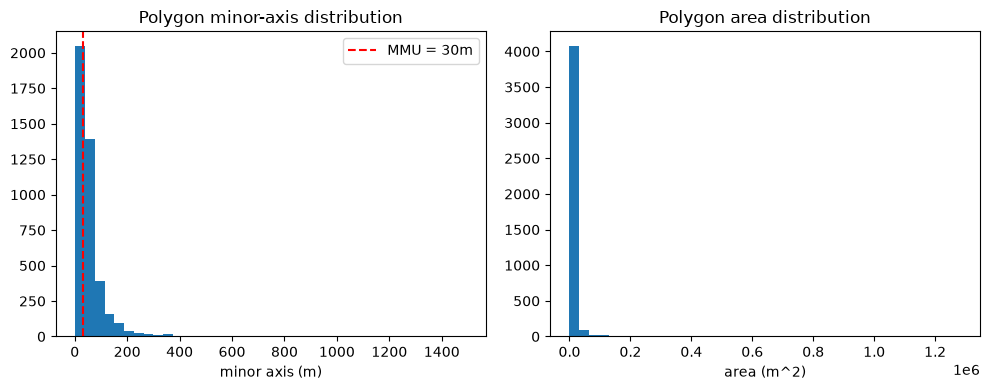

count    4225.000000
mean       58.128635
std        65.213342
min         1.940956
25%        27.566060
50%        40.024624
75%        64.462899
max      1493.338089
Name: minor_axis_m, dtype: float64
count    4.225000e+03
mean     7.404178e+03
std      2.559350e+04
min      5.417242e+00
25%      1.384455e+03
50%      3.044116e+03
75%      6.416253e+03
max      1.283126e+06
Name: area_m2, dtype: float64


In [7]:
labels["area_m2"] = labels.geometry.area

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(labels["minor_axis_m"], bins=40)
axes[0].axvline(MIN_MAPPABLE_UNIT_M, color="red", linestyle="--", label=f"MMU = {MIN_MAPPABLE_UNIT_M}m")
axes[0].set_title("Polygon minor-axis distribution")
axes[0].set_xlabel("minor axis (m)")
axes[0].legend()

axes[1].hist(labels["area_m2"], bins=40)
axes[1].set_title("Polygon area distribution")
axes[1].set_xlabel("area (m^2)")
plt.tight_layout()
plt.show()

print(labels["minor_axis_m"].describe())
print(labels["area_m2"].describe())

## Step 2 -- Data acquisition & preprocessing

**Pre-event only.** Every scene must date strictly before Nov 28, 2025 -- checked mechanically after download (`verify_pre_event_dates`), not just requested.

**CRS is forced, not assumed.** Both downloads force EPSG:32644 @ 10m -- Copernicus DEM is natively EPSG:4326 otherwise.

Band subset (visible + red edge + NIR + SWIR): matches or beats full 13-band input while avoiding the Hughes phenomenon.

### 2.1 — Acquisition helpers

Here we define `connect()` (CDSE OIDC auth), `download_sentinel2()`/`download_dem()` (query + CRS-force + download), and `verify_pre_event_dates()` (the mechanical post-download date check) — nothing in this cell touches the network yet, it only defines functions and self-checks them against synthetic fixtures.

In [8]:
def connect():
    con = openeo.connect("openeo.dataspace.copernicus.eu")
    con.authenticate_oidc_client_credentials(
        client_id=os.environ["CDSE_CLIENT_ID"],
        client_secret=os.environ["CDSE_CLIENT_SECRET"],
    )
    return con


def _search_start(s2_cfg):
    cutoff = date.fromisoformat(s2_cfg["pre_event_cutoff"])
    return (cutoff - timedelta(days=s2_cfg["search_window_days"])).isoformat()


def verify_pre_event_dates(path, cutoff_iso):
    """Enforces the pre-event constraint on the actual downloaded file, not
    just the request filter. Handles .nc (sync) and openEO_<date>Z.tif (batch).
    """
    cutoff = date.fromisoformat(cutoff_iso)
    path = Path(path)
    if path.suffix == ".nc":
        import xarray as xr
        with xr.open_dataset(path) as ds:
            time_dim = next((d for d in ("t", "time") if d in ds.coords), None)
            if time_dim is None:
                raise ValueError(f"{path}: no time coordinate found (expected 't' or 'time')")
            bad = [str(t) for t in ds[time_dim].values if pd.Timestamp(t).date() >= cutoff]
        if bad:
            raise ValueError(f"{path}: {len(bad)} timestamp(s) on/after {cutoff_iso} — pre-event constraint violated: {bad[:3]}")
        return

    name = path.name
    if not (name.startswith("openEO_") and name.endswith("Z.tif")):
        raise ValueError(f"{path}: unrecognized filename pattern — cannot verify pre-event compliance.")
    sensing_date = date.fromisoformat(name[len("openEO_"):-len("Z.tif")])
    if sensing_date >= cutoff:
        raise ValueError(f"{path}: sensing date {sensing_date} on/after {cutoff_iso} — pre-event constraint violated")


def _build_sentinel2_cube(con, cfg, spatial_extent=None):
    """Shared query builder for sync/batch; spatial_extent overrides cfg['aoi'] for per-tile jobs."""
    aoi, s2 = cfg["aoi"], cfg["sentinel2"]
    extent = spatial_extent or {"west": aoi["min_lon"], "south": aoi["min_lat"],
                                 "east": aoi["max_lon"], "north": aoi["max_lat"]}
    cube = con.load_collection(
        s2["collection"],
        spatial_extent=extent,
        temporal_extent=[_search_start(s2), s2["pre_event_cutoff"]],
        bands=s2["bands"],
        properties={"eo:cloud_cover": lambda v: v <= s2["max_cloud_cover"]},
    )
    epsg = int(cfg["target_crs"].split(":")[1])
    return cube.resample_spatial(resolution=cfg["target_resolution_m"], projection=epsg)


def aoi_tiles(aoi, n_lon=2, n_lat=2, overlap_m=0):
    """Splits the AOI into an n_lon x n_lat grid (avoids OOM on one big job).
    overlap_m pads tiles outward so a polygon near an internal seam still
    gets a full-margin patch from at least one tile.
    """
    lons = np.linspace(aoi["min_lon"], aoi["max_lon"], n_lon + 1)
    lats = np.linspace(aoi["min_lat"], aoi["max_lat"], n_lat + 1)
    mean_lat = (aoi["min_lat"] + aoi["max_lat"]) / 2
    lon_pad = overlap_m / (111_320 * np.cos(np.radians(mean_lat)))
    lat_pad = overlap_m / 111_320
    return [
        {"west": lons[i] - lon_pad, "east": lons[i + 1] + lon_pad,
         "south": lats[j] - lat_pad, "north": lats[j + 1] + lat_pad}
        for i in range(n_lon) for j in range(n_lat)
    ]


_tiles_check = aoi_tiles({"min_lon": 0, "max_lon": 10, "min_lat": 0, "max_lat": 10}, n_lon=2, n_lat=2)
assert len(_tiles_check) == 4
assert _tiles_check[0] == {"west": 0.0, "east": 5.0, "south": 0.0, "north": 5.0}


def download_sentinel2(cfg, out_dir):
    """Sync download for small/pilot AOIs -- CDSE's sync endpoint kills
    requests after 15min; use download_sentinel2_batch at country scale.
    """
    con = connect()
    cube = _build_sentinel2_cube(con, cfg)
    out_path = Path(out_dir) / "sentinel2_pre_event.nc"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    _retry_on_429(cube.download, out_path)
    verify_pre_event_dates(out_path, cfg["sentinel2"]["pre_event_cutoff"])
    return out_path


def _download_resumable(asset, target, max_retries=6):
    """Streams one asset with Range-based resume -- download_files() restarts from byte 0 on every drop."""
    from openeo.rest import OpenEoApiPlainError
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    con = asset.job.connection
    for attempt in range(1, max_retries + 1):
        existing = target.stat().st_size if target.exists() else 0
        headers = {"Range": f"bytes={existing}-"} if existing else {}
        try:
            with con.get(path=asset.href, headers=headers, stream=True) as r:
                r.raise_for_status()
                # 200 (not 206) means the server ignored our Range header -- don't trust it as a resume
                resumed = existing and r.status_code == 206
                with target.open("ab" if resumed else "wb") as f:
                    for block in r.iter_content(chunk_size=10 * 1024 * 1024):
                        f.write(block)
            return target
        except (requests.exceptions.ChunkedEncodingError, requests.exceptions.ConnectionError) as e:
            if attempt == max_retries:
                raise
            wait_s = 2 ** attempt
            got = target.stat().st_size if target.exists() else 0
            print(f"    Download dropped ({e.__class__.__name__}) at {got / 1e6:.0f}MB, resuming in {wait_s}s ({attempt}/{max_retries})...")
            time.sleep(wait_s)
        except OpenEoApiPlainError as e:
            # 416 = server rejected the resume outright -- discard partial, restart from scratch
            if existing and getattr(e, "http_status_code", None) == 416 and attempt < max_retries:
                print(f"    Server rejected resume (416) at {existing / 1e6:.0f}MB -- "
                      f"discarding partial file, restarting from scratch ({attempt}/{max_retries})...")
                target.unlink()
                continue
            raise


def _retry_on_429(fn, *args, max_retries=6, **kwargs):
    """openEO's POST endpoints (create_job, job.start, cube.download) get zero
    built-in retry on 429 -- only GET is retried transparently by urllib3.
    Retry the 429 case here with exponential backoff; anything else re-raises."""
    from openeo.rest import OpenEoApiPlainError
    for attempt in range(1, max_retries + 1):
        try:
            return fn(*args, **kwargs)
        except OpenEoApiPlainError as e:
            if getattr(e, "http_status_code", None) != 429 or attempt == max_retries:
                raise
            wait_s = 2 ** attempt
            print(f"    Rate-limited (429), retrying in {wait_s}s ({attempt}/{max_retries})...")
            time.sleep(wait_s)


def _start_and_wait_retrying(job, max_retries=6, max_poll_interval=60):
    """job.start_and_wait() calls job.start() again on every retry, even
    for a 429/dropped-connection raised late during polling -- retries
    start() and polling separately so that never resubmits. Poll interval
    backs off 5s -> max_poll_interval instead of hammering the endpoint.
    """
    from openeo.rest import OpenEoApiPlainError
    _retry_on_429(job.start)
    retries_left = max_retries
    poll_interval = min(5, max_poll_interval)
    status = None
    while True:
        try:
            status = job.describe().get("status", "N/A")
        except (OpenEoApiPlainError, requests.exceptions.ConnectionError) as e:
            is_429 = isinstance(e, OpenEoApiPlainError) and getattr(e, "http_status_code", None) == 429
            is_conn_drop = isinstance(e, requests.exceptions.ConnectionError)
            if (is_429 or is_conn_drop) and retries_left > 0:
                retries_left -= 1
                time.sleep(5)
                continue
            raise
        if status not in ("submitted", "created", "queued", "running"):
            break
        time.sleep(poll_interval)
        poll_interval = min(poll_interval * 1.25, max_poll_interval)
    if status != "finished":
        raise RuntimeError(f"Batch job {job.job_id!r} did not finish successfully (status={status}).")
    return job


def _download_one_sentinel2_tile(i, tile, cfg, out_dir, max_download_retries):
    """One tile's submit-wait-download-verify pipeline, run concurrently
    per tile. Own connect() per thread, not a shared Connection -- openEO's
    client isn't documented as thread-safe.
    """
    tile_dir = out_dir / f"tile{i}"
    _cached = sorted(tile_dir.glob("openEO_*.tif")) if tile_dir.exists() else []
    if _cached:
        # Already downloaded in an earlier session. The pre-event rule is still
        # verified below, so skipping the download does not skip the check.
        for p in _cached:
            verify_pre_event_dates(p, cfg["sentinel2"]["pre_event_cutoff"])
        print(f"--- Tile {i + 1}: reusing {len(_cached)} cached date(s), download skipped ---")
        return i, tile_dir

    print(f"--- Tile {i + 1}: submitting {tile} ---")
    con = connect()
    cube = _build_sentinel2_cube(con, cfg, spatial_extent=tile)
    time.sleep(i * 1.5)  # stagger submits -- N parallel POSTs at once trip CDSE's 429 rate limit
    job = _retry_on_429(con.create_job, cube, title=f"sentinel2_pre_event_tile{i}", job_options=cfg.get("batch_job_options"))
    _start_and_wait_retrying(job)

    tile_dir = out_dir / f"tile{i}"
    for asset in job.get_results().get_assets():
        _download_resumable(asset, tile_dir / asset._make_filename(), max_retries=max_download_retries)

    tif_paths = sorted(tile_dir.glob("openEO_*.tif"))
    if not tif_paths:
        raise ValueError(
            f"Tile {i} ({tile}) returned zero dates within the {cfg['sentinel2']['search_window_days']}-day "
            f"window at {cfg['sentinel2']['max_cloud_cover']}% cloud cover -- failing loudly instead of "
            "silently proceeding with a gap in the AOI. Widen search_window_days or max_cloud_cover for this run."
        )
    for p in tif_paths:
        verify_pre_event_dates(p, cfg["sentinel2"]["pre_event_cutoff"])
    print(f"--- Tile {i + 1}: done ---")
    return i, tile_dir


MAX_CONCURRENT_OPENEO_CONNECTIONS = 3  # CDSE backend caps concurrent connections per account at 3 (seen in its own 429 body)


def download_sentinel2_batch(cfg, out_dir, max_download_retries=6):
    """One openEO batch job per AOI tile -- avoids the sync 15min kill and
    the untiled job's backend OOM. Tiles run concurrently (each is a fully
    independent job+download), so wall time is bounded by the slowest tile,
    not the sum of all of them. One directory per tile, one GeoTIFF per date.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed
    tile_overlap_m = (preprocessing_cfg["patch"]["size_px"] // 2) * preprocessing_cfg["patch"]["resolution_m"]
    tiles = aoi_tiles(cfg["aoi"], overlap_m=tile_overlap_m, **cfg.get("tile_grid", {"n_lon": 2, "n_lat": 2}))
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    results = {}
    with ThreadPoolExecutor(max_workers=min(len(tiles), MAX_CONCURRENT_OPENEO_CONNECTIONS)) as executor:
        futures = [executor.submit(_download_one_sentinel2_tile, i, tile, cfg, out_dir, max_download_retries)
                   for i, tile in enumerate(tiles)]
        for future in as_completed(futures):
            i, tile_dir = future.result()  # re-raises immediately if this tile failed
            results[i] = tile_dir
    return [results[i] for i in range(len(tiles))]


def _download_one_dem_tile(i, tile, cfg, out_dir, epsg):
    """One tile's DEM download -- run concurrently per tile (download_dem),
    same reasoning and own-connect()-per-thread pattern as
    _download_one_sentinel2_tile.
    """
    con = connect()
    cube = con.load_collection(cfg["dem"]["source"], spatial_extent=tile)
    cube = cube.resample_spatial(resolution=cfg["target_resolution_m"], projection=epsg)
    tile_path = out_dir / f"dem_tile{i}.tif"
    time.sleep(i * 1.5)  # stagger -- same 429 rate limit as sentinel2 tiles
    _retry_on_429(cube.download, tile_path, job_options=cfg.get("batch_job_options"))
    return i, tile_path


def download_dem(cfg, out_dir):
    """Downloads Copernicus DEM per AOI tile (concurrently -- each tile is
    independent), reprojects each onto one shared grid, and merges --
    avoids seam misalignment from independent per-tile reprojection.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed
    _cached_dem = Path(out_dir) / "dem.tif"
    if _cached_dem.exists():
        print(f"Reusing cached DEM at {_cached_dem}, download and merge skipped.")
        return _cached_dem
    epsg = int(cfg["target_crs"].split(":")[1])
    tile_overlap_m = (preprocessing_cfg["patch"]["size_px"] // 2) * preprocessing_cfg["patch"]["resolution_m"]
    tiles = aoi_tiles(cfg["aoi"], overlap_m=tile_overlap_m, **cfg.get("tile_grid", {"n_lon": 2, "n_lat": 2}))

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    results = {}
    with ThreadPoolExecutor(max_workers=min(len(tiles), MAX_CONCURRENT_OPENEO_CONNECTIONS)) as executor:
        futures = [executor.submit(_download_one_dem_tile, i, tile, cfg, out_dir, epsg)
                   for i, tile in enumerate(tiles)]
        for future in as_completed(futures):
            i, tile_path = future.result()
            results[i] = tile_path
    tile_paths = [results[i] for i in range(len(tiles))]

    # Reproject every tile onto one shared, explicitly-computed grid rather than
    # rasterio.merge (which doesn't resample -- can leave a 0-valued seam gap).
    from rasterio.warp import transform_bounds, reproject, Resampling
    aoi = cfg["aoi"]
    west, south, east, north = transform_bounds(
        "EPSG:4326", cfg["target_crs"], aoi["min_lon"], aoi["min_lat"], aoi["max_lon"], aoi["max_lat"])
    res = cfg["target_resolution_m"]
    full_width = int(np.ceil((east - west) / res))
    full_height = int(np.ceil((north - south) / res))
    full_transform = from_origin(west, north, res, res)

    out_path = out_dir / "dem.tif"
    mosaic = None
    for tile_path in tile_paths:
        with rasterio.open(tile_path) as src:
            if mosaic is None:
                mosaic = np.zeros((src.count, full_height, full_width), dtype=src.dtypes[0])
                dtype, count = src.dtypes[0], src.count
            for b in range(src.count):
                reproject(
                    source=rasterio.band(src, b + 1),
                    destination=mosaic[b],
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=full_transform, dst_crs=cfg["target_crs"],
                    resampling=Resampling.bilinear,
                    init_dest_nodata=False,  # True wipes the WHOLE dest array every call, not just this tile's region
                )

    with rasterio.open(
        out_path, "w", driver="GTiff", height=full_height, width=full_width,
        count=count, dtype=dtype, crs=cfg["target_crs"], transform=full_transform,
    ) as dst:
        dst.write(mosaic)

    with rasterio.open(out_path) as ref:
        actual = f"EPSG:{ref.crs.to_epsg()}" if ref.crs else None
        if actual != cfg["target_crs"]:
            raise ValueError(
                f"{out_path}: expected {cfg['target_crs']}, got {actual} -- resample_spatial "
                "did not take effect as expected. REQUIRES VERIFICATION against the live backend."
            )
    return out_path


assert _search_start({"pre_event_cutoff": "2025-11-28", "search_window_days": 90}) == "2025-08-30"

import tempfile
import xarray as xr

with tempfile.TemporaryDirectory() as _tmp:
    _good = Path(_tmp) / "good.nc"
    _bad = Path(_tmp) / "bad.nc"
    xr.Dataset({"B04": (("t", "y", "x"), np.zeros((2, 2, 2)))},
               coords={"t": pd.to_datetime(["2025-08-01", "2025-09-15"])}).to_netcdf(_good)
    xr.Dataset({"B04": (("t", "y", "x"), np.zeros((2, 2, 2)))},
               coords={"t": pd.to_datetime(["2025-08-01", "2025-12-01"])}).to_netcdf(_bad)

    verify_pre_event_dates(_good, "2025-11-28")  # must not raise
    _rejected = False
    try:
        verify_pre_event_dates(_bad, "2025-11-28")
    except ValueError:
        _rejected = True
    assert _rejected, "verify_pre_event_dates should have rejected a post-event timestamp"

### 2.2 — Run Sentinel-2 download

Here we actually call `download_sentinel2_batch()` against the real, full-country AOI — the first cell in the notebook that touches the live network. **Confirmed, not hypothetical:** a plain synchronous `download_sentinel2()` call against this AOI (~150 x 165 km, multiple Sentinel-2 tiles, 90-day window) was tried and killed server-side by CDSE after exactly 15 minutes (`SPARK_JOB_CANCELLED ... PT15M`) — the batch path below is required at this scale, not just a fallback for a slow connection. `download_sentinel2()` (sync) still exists for small/pilot AOIs, where it's faster to iterate with.

In [9]:
s2_paths = download_sentinel2_batch(acquisition_cfg, DATA_DIR / acquisition_cfg["output_dir"] / "sentinel2")
print(f"Saved {len(s2_paths)} file(s): {s2_paths}")

--- Tile 1/4: {'west': np.float64(80.00838626601478), 'east': np.float64(80.72159173398524), 'south': np.float64(6.5510726169601154), 'north': np.float64(7.326472883039885)} ---
0:00:00 Job 'j-26082807523247d690d6a2fe8659bd51': send 'start'
0:00:02 Job 'j-26082807523247d690d6a2fe8659bd51': created (progress 0%)
0:00:08 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:00:14 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:00:22 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:00:32 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:00:45 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:01:00 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:01:20 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:01:44 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:02:14 Job 'j-26082807523247d690d6a2fe8659bd51': queued (progress 0%)
0:02:51 Job 'j-26082807523247d690d6a2fe8659bd51'

### 2.3 — Run DEM download

Here we call `download_dem()` for the same AOI — static terrain, no date filter, but the same CRS-forcing and live-network caveats as 2.2 apply.

In [10]:
dem_path = download_dem(acquisition_cfg, DATA_DIR / acquisition_cfg["output_dir"] / "dem")
print(f"Saved {dem_path}")

Saved f:\Landslide-Forecasting-System\data\raw\dem\dem.tif


### 2.4 — Cloud masking

Here we define `cloud_free_mask()`, which flags Scene Classification Layer pixels to exclude (cloud, shadow, cirrus) so they never enter a training patch unmasked.

In [11]:
SCL_EXCLUDE = set(preprocessing_cfg["cloud_mask"]["scl_exclude"])  # cloud shadow, unclassified, cloud med/high prob, cirrus


def cloud_free_mask(scl):
    """True where usable -- cloud shadows especially matter, they mimic saturated landslide scars."""
    return ~np.isin(scl, list(SCL_EXCLUDE))


_test_scl = np.array([4, 3, 7, 8, 9, 10, 5])  # 4=vegetation, 5=bare soil kept; rest excluded
assert cloud_free_mask(_test_scl).tolist() == [True, False, False, False, False, False, True]

### 2.5 — Spectral indices

Here we define reflectance scaling and three spectral indices — NDVI, BSI, MNDWI — each a normalized band ratio that highlights vegetation loss, exposed soil, and water, respectively.

In [12]:
REFLECTANCE_SCALE = preprocessing_cfg["reflectance_scale"]  # L2A digital numbers -> reflectance [0, 1]


def to_reflectance(dn):
    return dn.astype(np.float32) * REFLECTANCE_SCALE


def _safe_ratio(numerator, denominator):
    # denominator can hit exactly 0 on masked/no-data pixels.
    safe_denom = np.where(denominator == 0, 1, denominator)
    return np.where(denominator == 0, 0.0, numerator / safe_denom)


def ndvi(red, nir):
    return _safe_ratio(nir - red, nir + red)


def bsi(blue, red, nir, swir1):
    return _safe_ratio((swir1 + red) - (nir + blue), (swir1 + red) + (nir + blue))


def mndwi(green, swir1):
    return _safe_ratio(green - swir1, green + swir1)


assert to_reflectance(np.array([10000]))[0] == 1.0
assert np.allclose(ndvi(np.array([0.1, 0.5]), np.array([0.4, 0.5])), [0.6, 0.0])
assert ndvi(np.array([0.0]), np.array([0.0]))[0] == 0.0

# bsi/mndwi share ndvi's formula shape, so a transposed band argument is
# an easy mistake -- both checked explicitly, not just ndvi.
_blue, _red, _nir, _swir1, _green = (np.array([v]) for v in (0.1, 0.2, 0.5, 0.3, 0.15))
assert np.allclose(bsi(_blue, _red, _nir, _swir1), [((0.3 + 0.2) - (0.5 + 0.1)) / ((0.3 + 0.2) + (0.5 + 0.1))])
assert np.allclose(mndwi(_green, _swir1), [(0.15 - 0.3) / (0.15 + 0.3)])
assert mndwi(np.array([0.0]), np.array([0.0]))[0] == 0.0

### 2.6 — Terrain: slope & aspect

Here we compute slope (steepness) and aspect (downhill compass direction) from the DEM via finite-difference gradients — two of the three terrain channels that go into every patch.

In [13]:
def slope_aspect(dem, resolution_m):
    """Slope (degrees) and aspect (compass degrees) via finite-difference
    gradients. float32, not float64 -- runs on full tiles (tens of millions
    of pixels), float64 doubles memory for no precision benefit here.
    """
    dzdy, dzdx = np.gradient(dem.astype(np.float32), resolution_m)
    slope = np.degrees(np.arctan(np.hypot(dzdx, dzdy)))
    aspect = np.degrees(np.arctan2(-dzdx, dzdy)) % 360
    return slope, aspect


# Eastward-rising plane -> slope faces west -> aspect ~270 deg.
_plane_e = np.fromfunction(lambda r, c: c * 5.0, (10, 10))
_slope_e, _aspect_e = slope_aspect(_plane_e, resolution_m=10)
assert np.allclose(_slope_e[2:-2, 2:-2], np.degrees(np.arctan(0.5)), atol=0.5)
assert np.allclose(_aspect_e[2:-2, 2:-2], 270.0, atol=1.0)

# Southward-rising plane -> slope faces north -> aspect ~0 deg (catches a row-axis sign flip).
_plane_s = np.fromfunction(lambda r, c: r * 5.0, (10, 10))
_slope_s, _aspect_s = slope_aspect(_plane_s, resolution_m=10)
assert np.allclose(_aspect_s[2:-2, 2:-2] % 360, 0.0, atol=1.0)

### 2.7 — Terrain: curvature

Here we compute profile curvature (whether terrain is convex/ridge or concave/valley) — the third terrain channel alongside slope/aspect.

In [14]:
def curvature(dem, resolution_m):
    """Profile curvature: positive = convex/ridge, negative = concave/valley.
    -(d2z/dx2 + d2z/dy2) via two np.gradient passes; float32 for the same
    memory reason as slope_aspect.
    """
    dzdy, dzdx = np.gradient(dem.astype(np.float32), resolution_m)
    d2zdy2, _ = np.gradient(dzdy, resolution_m)
    _, d2zdx2 = np.gradient(dzdx, resolution_m)
    return -(d2zdx2 + d2zdy2)


# Dome (peak center) = ridge -> curvature > 0.
_dome = np.fromfunction(lambda r, c: -0.05 * ((r - 30) ** 2 + (c - 30) ** 2), (60, 60))
_curv_dome = curvature(_dome, resolution_m=1)
assert np.all(_curv_dome[10:-10, 10:-10] > 0)

# Bowl (trough center) = valley -> curvature < 0.
_bowl = np.fromfunction(lambda r, c: 0.05 * ((r - 30) ** 2 + (c - 30) ** 2), (60, 60))
_curv_bowl = curvature(_bowl, resolution_m=1)
assert np.all(_curv_bowl[10:-10, 10:-10] < 0)

### 2.8 — Label rasterization

Here we burn the label polygons into a pixel mask aligned to the imagery grid, splitting off polygons under the minimum mappable unit into a separate small-object mask instead of dropping or blending them in.

In [15]:
def rasterize_labels(labels_gdf, shape, transform, min_minor_axis_m=None):
    """Burns polygons to a pixel mask. Below the minimum mappable unit go
    to a separate small-object mask (recall tracked, not dropped/blended).
    all_touched=True so a sub-pixel polygon can't vanish for missing a pixel center.
    """
    min_minor_axis_m = MIN_MAPPABLE_UNIT_M if min_minor_axis_m is None else min_minor_axis_m
    main = labels_gdf[labels_gdf["minor_axis_m"] >= min_minor_axis_m]
    small = labels_gdf[labels_gdf["minor_axis_m"] < min_minor_axis_m]
    return _burn(main, shape, transform), _burn(small, shape, transform)


def _burn(gdf, shape, transform):
    if len(gdf) == 0:
        return np.zeros(shape, dtype=np.uint8)
    return rasterize([(g, 1) for g in gdf.geometry], out_shape=shape, transform=transform,
                      fill=0, dtype=np.uint8, all_touched=True)


_ref_transform = from_origin(0, 200, 10, 10)  # 20x20 px @ 10m
_test_gdf = gpd.GeoDataFrame(
    {"minor_axis_m": [50.0, 10.0]},
    geometry=[box(20, 20, 70, 70), box(120, 120, 130, 130)],
    crs=METRIC_CRS,
)
_mask, _small_mask = rasterize_labels(_test_gdf, (20, 20), _ref_transform)
assert _mask.sum() > 0 and _small_mask.sum() > 0 and not np.any(_mask & _small_mask)

# box(21,21,24,24) misses pixel (25,25)'s center while still touching it --
# only passes if all_touched=True is really wired through.
_tiny = gpd.GeoDataFrame({"minor_axis_m": [8.0]}, geometry=[box(21, 21, 24, 24)], crs=METRIC_CRS)
_, _tiny_mask = rasterize_labels(_tiny, (20, 20), _ref_transform)
assert _tiny_mask.sum() > 0

### 2.9 — Patch tiling

Here we define the sliding-window generator that tiles a full scene into 256x256 @ 10m patches with 50% stride overlap, used by both training-time extraction and any full-scene inference pass.

In [16]:
def iter_patches(dataset, size=256, stride=128):
    """Yields (window, transform) tiling an OPEN rasterio dataset, full patches only."""
    for row in range(0, dataset.height - size + 1, stride):
        for col in range(0, dataset.width - size + 1, stride):
            window = Window(col, row, size, size)
            yield window, dataset.window_transform(window)


# Non-square raster so a height/width axis swap would show up (a square fixture can't catch it).
with MemoryFile() as _memfile:
    with _memfile.open(driver="GTiff", height=640, width=512, count=1, dtype="uint8",
                        crs=METRIC_CRS, transform=from_origin(0, 640, 1, 1)) as _ds:
        _ds.write(np.zeros((640, 512), dtype=np.uint8), 1)
    with _memfile.open() as _ds:
        _patches = list(iter_patches(_ds, size=256, stride=128))
_row_offs = sorted({w.row_off for w, _ in _patches})
_col_offs = sorted({w.col_off for w, _ in _patches})
assert len(_row_offs) == 4  # (640-256)/128 + 1
assert len(_col_offs) == 3  # (512-256)/128 + 1
assert len(_patches) == 12

### 2.10 — Patch extraction

Here we tie 2.4–2.9 together: crop one window's worth of bands/SCL/DEM, cloud-mask it, compute indices + terrain, and stack everything into the final (channels, H, W) array a model actually consumes.

In [17]:
BAND_ORDER = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]


def extract_patch(bands, scl, dem, window, resolution_m, terrain_margin_px=2):
    """Cloud-masks, computes indices + terrain, stacks into (channels, H, W).
    Terrain derivatives are computed on the window plus a small margin
    (not cropped-then-derived), so border pixels get real neighboring
    context instead of a one-sided finite difference.
    """
    row0, col0, h, w = window.row_off, window.col_off, window.height, window.width
    cropped = {b: bands[b] for b in BAND_ORDER if b in bands}
    mask = cloud_free_mask(scl)

    channels = [cropped[b] for b in BAND_ORDER if b in cropped]
    if "B04" in cropped and "B08" in cropped:
        channels.append(ndvi(cropped["B04"], cropped["B08"]))
    if all(k in cropped for k in ("B02", "B04", "B08", "B11")):
        channels.append(bsi(cropped["B02"], cropped["B04"], cropped["B08"], cropped["B11"]))
    if "B03" in cropped and "B11" in cropped:
        channels.append(mndwi(cropped["B03"], cropped["B11"]))

    pad = terrain_margin_px
    r0, r1 = max(row0 - pad, 0), min(row0 + h + pad, dem.shape[0])
    c0, c1 = max(col0 - pad, 0), min(col0 + w + pad, dem.shape[1])
    dem_padded = dem[r0:r1, c0:c1]
    slope_p, aspect_p = slope_aspect(dem_padded, resolution_m)
    curv_p = curvature(dem_padded, resolution_m)
    sr0, sc0 = row0 - r0, col0 - c0
    slope = slope_p[sr0:sr0 + h, sc0:sc0 + w]
    aspect = aspect_p[sr0:sr0 + h, sc0:sc0 + w]
    curv = curv_p[sr0:sr0 + h, sc0:sc0 + w]
    channels.extend([slope, aspect, curv])

    stack = np.stack(channels).astype(np.float32)
    stack = stack * mask  # zero cloud/shadow pixels
    return stack, mask


_h = _w = 20
_syn_dem = np.fromfunction(lambda r, c: c * 2.0, (_h, _w))
_syn_window = Window(2, 2, 10, 10)

# bands/scl simulate a real windowed disk read: already patch-sized (10x10)
_syn_bands = {b: np.random.rand(10, 10).astype(np.float32) for b in ("B02", "B03", "B04", "B08", "B11")}
_syn_scl = np.full((10, 10), 4, dtype=np.uint8)
_syn_scl[0:5, 0:5] = 9  # a cloud patch

_stack, _mask = extract_patch(_syn_bands, _syn_scl, _syn_dem, _syn_window, resolution_m=10)
assert _stack.shape == (5 + 3 + 3, 10, 10)  # 5 bands + NDVI/BSI/MNDWI + slope/aspect/curvature
assert (_stack[:, 0:5, 0:5] == 0).all()  # cloud patch zeroed

### 2.11 — Load real acquisition outputs

Here we define `load_sentinel2_tile_dates()` (lists each tile's per-date GeoTIFF paths plus the shared transform/resolution — no pixel data read yet) and `load_dem_aligned()` (resamples the DEM onto that exact pixel grid). Actual pixel reads happen later, per patch, in `LandslideDataset.__getitem__` (4.1) — this is metadata-only glue between a real download (2.2/2.3) and that lazy read path.

In [18]:
def load_sentinel2_tile_dates(tile_dir):
    """Lists per-date GeoTIFF paths + shared transform/resolution -- metadata
    only. Real pixel reads happen later, per-patch, in LandslideDataset.
    """
    tif_paths = sorted(Path(tile_dir).glob("openEO_*.tif"))
    if not tif_paths:
        raise ValueError(f"{tile_dir}: no 'openEO_*.tif' files found")
    with rasterio.open(tif_paths[0]) as src:
        transform, resolution_m = src.transform, abs(src.transform.a)
    per_date = [(p, p.name[len("openEO_"):-len("Z.tif")]) for p in tif_paths]
    return per_date, transform, resolution_m


def load_dem_aligned(dem_path, target_transform, target_shape, target_crs):
    """DEM resampled onto the Sentinel-2 scene's exact pixel grid (openEO
    can offset collections by a fraction of a pixel).
    """
    from rasterio.warp import reproject, Resampling
    with rasterio.open(dem_path) as src:
        dem = np.zeros(target_shape, dtype=np.float32)
        reproject(source=rasterio.band(src, 1), destination=dem,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=target_transform, dst_crs=target_crs,
                  resampling=Resampling.bilinear)
    return dem


with tempfile.TemporaryDirectory() as _tmp_dem:
    _dem_check_path = Path(_tmp_dem) / "dem.tif"
    _src_transform = from_origin(1000, 2000, 10, 10)
    _src_dem = np.fromfunction(lambda r, c: c * 1.0, (50, 50)).astype(np.float32)
    with rasterio.open(_dem_check_path, "w", driver="GTiff", height=50, width=50, count=1,
                        dtype="float32", crs=METRIC_CRS, transform=_src_transform) as _dst:
        _dst.write(_src_dem, 1)
    _aligned_dem = load_dem_aligned(_dem_check_path, from_origin(1002, 1998, 10, 10), (50, 50), METRIC_CRS)
assert _aligned_dem.shape == (50, 50)
assert _aligned_dem.max() > 0

Run once you have real `s2_paths`/`dem_path` from 2.2/2.3 — this cell needs live download output and is not executed automatically. `s2_paths` is a list of per-tile directories (one per AOI tile, `aoi_tiles`), each holding one GeoTIFF per pre-event date; this just counts dates per tile, it doesn't load any pixels.

In [19]:
print(f"{len(s2_paths)} tile(s) downloaded.")
for _tile_dir in s2_paths:
    _tif_paths = sorted(Path(_tile_dir).glob("openEO_*.tif"))
    _dates = [p.name[len("openEO_"):-len("Z.tif")] for p in _tif_paths]
    print(f"  {Path(_tile_dir).name}: {len(_dates)} pre-event date(s) -- {_dates}")

4 tile(s) downloaded.
  tile0: 3 pre-event date(s) -- ['2025-10-31', '2025-11-02', '2025-11-20']
  tile1: 3 pre-event date(s) -- ['2025-10-31', '2025-11-02', '2025-11-20']
  tile2: 2 pre-event date(s) -- ['2025-10-31', '2025-11-02']
  tile3: 2 pre-event date(s) -- ['2025-10-31', '2025-11-02']


## Step 3 -- Sample generation & spatial cross-validation

No district/date/severity attribute exists in the source data, so spatial clusters are computed here (K-Means). Negatives are slope-stratified (density-proportional) plus hard negatives adjacent to real failures -- not random.

### 3.1 — Spatial clustering

Here we run K-Means on polygon centroids to assign each label a cluster, then check the resulting cluster sizes are reasonably balanced — clusters are the unit that cross-validation folds hold out.

In [20]:
def assign_spatial_clusters(labels_gdf, n_clusters=None, random_state=None):
    """K-Means over polygon centroids -- no district/date field exists in the source data."""
    n_clusters = spatial_cv_cfg["clustering"]["n_clusters"] if n_clusters is None else n_clusters
    random_state = RANDOM_SEED if random_state is None else random_state
    centroids = np.column_stack([labels_gdf.geometry.centroid.x, labels_gdf.geometry.centroid.y])
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    return km.fit_predict(centroids)


labels["cluster"] = assign_spatial_clusters(labels)

# Flags (does not block) a very uneven K-Means split -- weakens that fold's metrics.
_cluster_share = labels["cluster"].value_counts(normalize=True).sort_index()
print(f"Cluster sizes: {dict(labels['cluster'].value_counts().sort_index())}")
print(f"Cluster share range: {_cluster_share.min():.1%} - {_cluster_share.max():.1%}")
if _cluster_share.max() > 0.30 or _cluster_share.min() < 0.02:
    print("NOTE: cluster sizes are notably imbalanced — treat that fold's metrics with extra caution.")
labels["cluster"].value_counts().sort_index()

Cluster sizes: {0: np.int64(438), 1: np.int64(839), 2: np.int64(281), 3: np.int64(632), 4: np.int64(385), 5: np.int64(607), 6: np.int64(237), 7: np.int64(806)}
Cluster share range: 5.6% - 19.9%


cluster
0    438
1    839
2    281
3    632
4    385
5    607
6    237
7    806
Name: count, dtype: int64

### 3.2 — Cluster visualization

Here we plot the label polygons colored by cluster, as a visual sanity check that clusters are spatially coherent, not scattered.

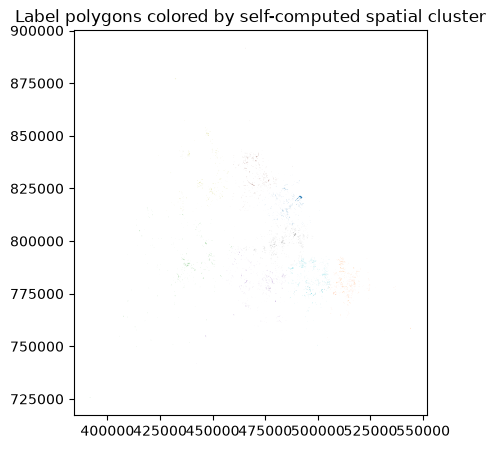

In [21]:
fig, ax = plt.subplots(figsize=(5, 5))
labels.plot(column="cluster", cmap="tab10", ax=ax, legend=False)
ax.set_title("Label polygons colored by self-computed spatial cluster")
ax.set_aspect("equal")
plt.show()

### 3.3 — Buffered cross-validation folds

Here we generate one fold per cluster, holding it out entirely and stripping any training polygon within the buffer distance of it — the mechanism that actually prevents spatial leakage between train and test.

In [22]:
def buffered_cluster_folds(gdf, cluster_col="cluster", buffer_m=None):
    """Yields (test_cluster_id, train_idx, test_idx), holding out one cluster
    with any train polygon within buffer_m excluded (strips spatial
    autocorrelation leakage). No random-fold option in this API.
    """
    buffer_m = spatial_cv_cfg["buffer_m"] if buffer_m is None else buffer_m
    patch_half_width_m = (preprocessing_cfg["patch"]["size_px"] // 2) * preprocessing_cfg["patch"]["resolution_m"]
    # a train patch and a test patch each independently extend patch_half_width_m
    # toward each other from their own sample point, so avoiding any shared pixel
    # requires the full patch width, not just one half-width.
    if buffer_m < 2 * patch_half_width_m:
        raise ValueError(
            f"buffer_m={buffer_m} is smaller than the full patch width "
            f"(2 * {patch_half_width_m}m) -- train/test patches could still "
            "share pixels across a fold boundary."
        )
    for test_cluster in sorted(gdf[cluster_col].unique()):
        test_mask = gdf[cluster_col] == test_cluster
        test_geom = gdf.loc[test_mask, "geometry"].union_all().buffer(buffer_m)
        train_mask = (~test_mask) & (~gdf.geometry.intersects(test_geom))
        yield test_cluster, gdf.index[train_mask].to_numpy(), gdf.index[test_mask].to_numpy()


_check_buffer_m = spatial_cv_cfg["buffer_m"]
for _test_cluster, _train_idx, _test_idx in buffered_cluster_folds(labels, buffer_m=_check_buffer_m):
    assert not set(_train_idx) & set(_test_idx)
    _test_geom = labels.loc[_test_idx, "geometry"].union_all().buffer(_check_buffer_m)
    assert not labels.loc[_train_idx, "geometry"].intersects(_test_geom).any()
print(f"{labels['cluster'].nunique()} clusters -> {labels['cluster'].nunique()} buffered folds, all leakage-checked")

8 clusters -> 8 buffered folds, all leakage-checked


### 3.4 — Positive sample windows

Here we convert a polygon centroid (world coordinates) into the pixel window used to crop a positive training patch around it.

In [23]:
def positive_patch_window(centroid_xy, transform, size=256):
    """Pixel window centered on a centroid. Caller must clip against raster bounds -- not handled here."""
    col, row = ~transform * centroid_xy
    half = size // 2
    # math.floor, not int(): int() truncates toward zero, wrong for negative fractional coords
    return Window(math.floor(col) - half, math.floor(row) - half, size, size)


# Asymmetric transform/centroid so a col/row swap would be caught.
_transform = from_origin(0, 1000, 10, 10)
_win = positive_patch_window((300, 500), _transform, size=256)
assert (_win.col_off, _win.row_off) == (30 - 128, 50 - 128)

_win_neg = positive_patch_window((-4, 500), _transform, size=256)  # negative fractional pixel coord
assert _win_neg.col_off == math.floor(-0.4) - 128 == -1 - 128

### 3.5 — Slope-stratified negative sampling

Here we pick negative-sample pixel locations so their slope distribution matches the positives' shape (not just random background), excluding anything too close to a real polygon.

In [24]:
def _to_points(candidates, transform):
    xs, ys = rasterio.transform.xy(transform, [r for r, c in candidates], [c for r, c in candidates])
    return gpd.GeoSeries([Point(x, y) for x, y in zip(xs, ys)], crs=METRIC_CRS)


def slope_stratified_negative_candidates(dem, transform, resolution_m, positive_slopes_deg,
                                          exclusion_geom, n_total=None, bins=None, rng=None, slope=None):
    """Negative candidates density-stratified to match the positive slope
    distribution -- random negatives are trivially separable by slope alone.
    slope, if given, skips recomputing it (tile-invariant across dates).
    """
    cfg = spatial_cv_cfg["negative_sampling"]
    n_total = 100 if n_total is None else n_total
    bins = cfg["slope_bins"] if bins is None else bins
    rng = rng or np.random.default_rng(RANDOM_SEED)

    if slope is None:
        slope, _ = slope_aspect(dem, resolution_m)
    edges = np.histogram_bin_edges(positive_slopes_deg, bins=bins)
    pos_counts, _ = np.histogram(positive_slopes_deg, bins=edges)
    # zero-density bins get zero negatives -- forcing >=1 there would draw
    # negatives from slope ranges no positive ever occupies, reintroducing
    # the slope-separability stratification is meant to remove.
    n_per_bin = np.where(
        pos_counts == 0, 0, np.maximum(1, np.round(n_total * pos_counts / max(pos_counts.sum(), 1)))
    ).astype(int)

    candidates = []
    n_bins = len(edges) - 1
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        is_last = i == n_bins - 1
        in_bin = (slope >= lo) & ((slope <= hi) if is_last else (slope < hi))
        rows, cols = np.where(in_bin)
        if len(rows) == 0:
            continue
        pick = rng.choice(len(rows), size=min(n_per_bin[i], len(rows)), replace=False)
        candidates.extend(zip(rows[pick], cols[pick]))

    if not candidates:
        return []
    points = _to_points(candidates, transform)
    keep = ~points.within(exclusion_geom)
    return [rc for rc, k in zip(candidates, keep) if k]


# Self-check 1: two different slope regions so both bins are genuinely exercised.
_strat_dem = np.zeros((60, 60))
for _col in range(60):
    _strat_dem[:, _col] = (1.0 * _col) if _col < 30 else (30.0 + 8.0 * (_col - 30))
_strat_slope, _ = slope_aspect(_strat_dem, resolution_m=10)
_no_op_exclusion = box(-1000, -1000, -999, -999)  # far away -> excludes nothing
_strat_candidates = slope_stratified_negative_candidates(
    _strat_dem, from_origin(0, 600, 10, 10), 10, positive_slopes_deg=np.array([5.0, 6.0, 38.0, 39.0, 40.0]),
    exclusion_geom=_no_op_exclusion, n_total=40, bins=4, rng=np.random.default_rng(1),
)
_cand_slopes = [_strat_slope[r, c] for r, c in _strat_candidates]
assert len(_cand_slopes) > 0
assert min(_cand_slopes) < 10 and max(_cand_slopes) > 30
# positive_slopes_deg=[5,6,38,39,40] with bins=4 -> edges [5, 13.75, 22.5, 31.25, 40];
# the two middle bins have zero positive representation, so no negative
# should ever be drawn from that dead zone.
assert all(s < 13.75 or s >= 31.25 for s in _cand_slopes)

# Self-check 2: exclusion-buffer correctness (uniform DEM isolates it from stratification).
_dem = np.fromfunction(lambda r, c: c * 2.0, (50, 50))
_transform2 = from_origin(0, 500, 10, 10)
_exclusion = box(-10, 390, 510, 510)  # excludes rows 0-11
_excl_candidates = slope_stratified_negative_candidates(
    _dem, _transform2, 10, positive_slopes_deg=np.array([5.0, 8.0, 12.0]),
    exclusion_geom=_exclusion, n_total=30, bins=3, rng=np.random.default_rng(1),
)
assert len(_excl_candidates) > 0
assert all(r >= 12 for r, c in _excl_candidates)

### 3.6 — Hard negative sampling

Here we pick negatives from a ring just outside each polygon's exclusion buffer — adjacent to real failures without overlapping them — so the model is tested on genuinely ambiguous terrain, not just easy background.

In [25]:
def hard_negative_candidates(dem, transform, exclusion_geom, ring_outer_geom, n_total=50, rng=None):
    """Negatives from the ring just outside the exclusion buffer -- adjacent
    to real failures without overlapping them. Rejection-samples within
    ring_outer_geom's bbox (not the full scene) so memory scales with
    n_total, not scene size.
    """
    rng = rng or np.random.default_rng(RANDOM_SEED)
    height, width = dem.shape
    minx, miny, maxx, maxy = ring_outer_geom.bounds

    ring_candidates, seen, attempts = [], set(), 0
    max_attempts = max(5000, n_total * 500)
    while len(ring_candidates) < n_total and attempts < max_attempts:
        batch = min(max(n_total * 10, 500), max_attempts - attempts)
        xs = rng.uniform(minx, maxx, size=batch)
        ys = rng.uniform(miny, maxy, size=batch)
        cols, rows = ~transform * (xs, ys)
        rows, cols = np.round(rows).astype(int), np.round(cols).astype(int)
        in_grid = (rows >= 0) & (rows < height) & (cols >= 0) & (cols < width)
        rows, cols = rows[in_grid], cols[in_grid]
        # snap to pixel center before testing -- must match what _to_points reconstructs downstream
        cx, cy = transform * (cols + 0.5, rows + 0.5)
        pts = gpd.GeoSeries([Point(x, y) for x, y in zip(cx, cy)], crs=METRIC_CRS)
        keep = (~pts.within(exclusion_geom)) & pts.within(ring_outer_geom)
        for r, c, k in zip(rows, cols, keep):
            if k and (r, c) not in seen:
                seen.add((r, c))
                ring_candidates.append((r, c))
        attempts += batch

    if len(ring_candidates) > n_total:
        idx = rng.choice(len(ring_candidates), size=n_total, replace=False)
        ring_candidates = [ring_candidates[i] for i in idx]
    return ring_candidates


_hn_dem = np.zeros((60, 60))
_hn_transform = from_origin(0, 600, 10, 10)
_hn_exclusion = box(200, 200, 400, 400)
_hn_ring_outer = box(100, 100, 500, 500)
_hard_negs = hard_negative_candidates(_hn_dem, _hn_transform, _hn_exclusion, _hn_ring_outer,
                                       n_total=20, rng=np.random.default_rng(2))
assert len(_hard_negs) > 0
_hn_points = _to_points(_hard_negs, _hn_transform)
assert not _hn_points.within(_hn_exclusion).any()
assert _hn_points.within(_hn_ring_outer).all()

### 3.7 — Provenance manifest

Here we define and persist the per-patch audit trail (source product, sensing date, cluster, positive/negative) that makes the pre-event-only constraint independently checkable rather than assumed.

In [26]:
def manifest_row(patch_id, product_id, sensing_date, cluster, is_positive):
    """One provenance-manifest row -- makes pre-event-only compliance independently checkable."""
    assert date.fromisoformat(sensing_date) < date.fromisoformat("2025-11-28"), (
        f"patch {patch_id}: sensing_date {sensing_date} is not strictly pre-event"
    )
    return {"patch_id": patch_id, "product_id": product_id, "sensing_date": sensing_date,
            "cluster": cluster, "is_positive": is_positive}


_manifest_rows = []


def append_to_manifest(row):
    _manifest_rows.append(row)


def save_manifest(path):
    """Persists accumulated manifest rows to disk."""
    df = pd.DataFrame(_manifest_rows)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return df


append_to_manifest(manifest_row("p0001", "S2B_MSIL2A_20250801T...", "2025-08-01", cluster=3, is_positive=True))

_rejected = False
try:
    manifest_row("bad", "x", "2025-12-01", cluster=0, is_positive=False)
except AssertionError:
    _rejected = True
assert _rejected, "should have rejected a post-event date"

_manifest_demo_path = DATA_DIR / "processed" / "manifest_demo.csv"
_saved = save_manifest(_manifest_demo_path)
assert _manifest_demo_path.exists() and len(_saved) == 1
print(f"Demo manifest persisted to {_manifest_demo_path} ({len(_saved)} row)")

Demo manifest persisted to f:\Landslide-Forecasting-System\data\processed\manifest_demo.csv (1 row)


## Step 4 -- Modeling

U-Net baseline + DeepLabV3+ comparison, both `segmentation_models_pytorch`, same 16-channel input stack. Focal+Dice loss (plain cross-entropy is invalid under this class imbalance).

Every check here is first proven on synthetic data before 4.2/4.6 run the same code against real imagery. See Step 6's status table.

### 4.1 — Dataset streaming

Here we wrap patch extraction in a PyTorch `Dataset` that reads one patch lazily per `__getitem__` call, instead of preloading the whole AOI into RAM.

In [27]:
class LandslideDataset(torch.utils.data.Dataset):
    """Lazily extracts one patch per sample from disk. Keeps one rasterio
    handle per instance (opened lazily, not per sample) -- cheap locally but
    a real cost on Drive-mounted storage. Safe with num_workers>0 on Colab:
    each forked worker opens its own handle after forking.
    """

    def __init__(self, centroids_xy, tif_path, dem, mask_full, transform, resolution_m, size=256):
        self.centroids_xy = centroids_xy
        self.tif_path = tif_path
        self.dem, self.mask_full = dem, mask_full
        self.transform, self.resolution_m, self.size = transform, resolution_m, size
        self._src = None

    def __len__(self):
        return len(self.centroids_xy)

    def __del__(self):
        if self._src is not None:
            self._src.close()

    def __getitem__(self, idx):
        window = positive_patch_window(self.centroids_xy[idx], self.transform, size=self.size)
        row0, col0, h, w = window.row_off, window.col_off, window.height, window.width
        # fail loud if the caller skipped margin-filtering (else this would silently wrap via slicing)
        if row0 < 0 or col0 < 0 or row0 + h > self.mask_full.shape[0] or col0 + w > self.mask_full.shape[1]:
            raise ValueError(
                f"patch window ({row0}, {col0}, {h}, {w}) falls outside mask_full "
                f"{self.mask_full.shape} -- centroid {self.centroids_xy[idx]} was not "
                "margin-filtered before reaching LandslideDataset."
            )
        if self._src is None:
            self._src = rasterio.open(self.tif_path)
        arr = self._src.read(window=window, boundless=True, fill_value=0)
        bands = {b: to_reflectance(arr[i]) for i, b in enumerate(BAND_ORDER)}
        scl = arr[len(BAND_ORDER)].astype(np.uint8)
        x, _ = extract_patch(bands, scl, self.dem, window, self.resolution_m)
        y = self.mask_full[row0:row0 + h, col0:col0 + w]
        return torch.from_numpy(x), torch.from_numpy(y.astype(np.float32))


_scene = 600
_ds_dem = np.fromfunction(lambda r, c: c * 1.5, (_scene, _scene))
_ds_mask_full = np.zeros((_scene, _scene), dtype=np.uint8)
_ds_transform = from_origin(0, _scene * 10, 10, 10)
_ds_centroids = [(2500, 2500), (3000, 3000)]

# a real temp GeoTIFF, exercises the actual windowed-disk-read path
with tempfile.TemporaryDirectory() as _ds_tmp:
    _ds_tif_path = Path(_ds_tmp) / "synthetic_scene.tif"
    _ds_arr = (np.random.rand(len(BAND_ORDER) + 1, _scene, _scene) * 3000).astype(np.int16)
    _ds_arr[-1] = 4  # SCL: clear vegetation everywhere
    with rasterio.open(_ds_tif_path, "w", driver="GTiff", height=_scene, width=_scene,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_ds_transform) as _dst:
        _dst.write(_ds_arr)

    _dataset = LandslideDataset(_ds_centroids, _ds_tif_path, _ds_dem, _ds_mask_full,
                                 _ds_transform, resolution_m=10, size=64)
    assert len(_dataset) == 2
    _x0, _y0 = _dataset[0]
    assert isinstance(_x0, torch.Tensor) and isinstance(_y0, torch.Tensor)
    assert _x0.shape == (len(BAND_ORDER) + 3 + 3, 64, 64)
    assert _y0.shape == (64, 64)
    del _dataset  # closes the open handle before the temp dir cleans up (Windows can't delete an open file)

### 4.2 — Assemble a real training sample set

Here we combine label loading (1.3), rasterization (2.8), and positive/negative/hard-negative sampling (3.4-3.6) into real `LandslideDataset`s — one per pre-event date per AOI tile, concatenated across every tile (`build_real_dataset_all_tiles`) — the assembly step connecting real downloaded imagery to actual training samples, distinct from each sampling function's own isolated self-check above.

In [28]:
def labels_within_bounds(labels_gdf, transform, shape, patch_size):
    """Keeps labels whose centroid is far enough from the scene edge for a
    full patch to fit. positive_patch_window floors the pixel coordinate
    first, so the true bound is coord < dim - half + 1, not dim - half.
    """
    height, width = shape
    half = patch_size // 2
    xs = labels_gdf.geometry.centroid.x.to_numpy()
    ys = labels_gdf.geometry.centroid.y.to_numpy()
    cols, rows = ~transform * (xs, ys)
    inside = (rows >= half) & (rows < height - half + 1) & (cols >= half) & (cols < width - half + 1)
    return labels_gdf[inside]


def _filter_candidates_by_margin(candidates, shape, patch_size):
    """candidates are already integer pixel indices (no floor() involved),
    so the fit condition is simply r/c <= dim - half (inclusive).
    """
    half = patch_size // 2
    height, width = shape
    return [(r, c) for r, c in candidates if half <= r <= height - half and half <= c <= width - half]


# Boundary case from positive_patch_window's own math: height=1000, half=128 ->
# a centroid at exact pixel row 872.0 gives row_off=floor(872.0)-128=744,
# 744+256=1000 -- fits the scene exactly and must not be rejected.
_lwb_transform = from_origin(0, 1000 * 10, 10, 10)
_lwb_labels = gpd.GeoDataFrame(
    {"minor_axis_m": [40.0]}, geometry=[Point(5000, 1280).buffer(5)], crs=METRIC_CRS)
assert len(labels_within_bounds(_lwb_labels, _lwb_transform, (1000, 1000), patch_size=256)) == 1
assert _filter_candidates_by_margin([(872, 500)], (1000, 1000), patch_size=256) == [(872, 500)]
print("labels_within_bounds / _filter_candidates_by_margin self-check: exact-boundary case included.")


_TILE_CONTEXT_CACHE = {}


def _tile_static_context(labels_gdf, positive_labels_gdf, dem, transform, resolution_m, patch_size,
                          cache_key=None):
    """Everything about a tile that does NOT depend on which date's imagery
    is being sampled (mask, slope, exclusion/ring geometry) -- computed once
    per tile by build_real_dataset_all_dates instead of once per date.
    """
    scene_shape = dem.shape
    # positives must be sampleable from mask_full, which itself excludes
    # sub-MMU polygons -- otherwise a small polygon becomes a "positive"
    # patch whose dense label is silently all zero.
    mmu_positive_labels_gdf = positive_labels_gdf[positive_labels_gdf["minor_axis_m"] >= MIN_MAPPABLE_UNIT_M]
    in_scene = labels_within_bounds(mmu_positive_labels_gdf, transform, scene_shape, patch_size)

    # The heavy parts below (full-scene rasterize, full-scene slope, and two
    # union_all calls over every buffered polygon in the inventory) depend only
    # on the tile, never on which polygons are eligible this fold -- so they are
    # computed once per tile and reused. in_scene above is the only fold-varying
    # piece, and it is recomputed every call.
    _key = (cache_key, scene_shape, patch_size)
    _hit = _TILE_CONTEXT_CACHE.get(_key) if cache_key is not None else None
    if _hit is None:
        mask_full, _ = rasterize_labels(labels_gdf, scene_shape, transform)
        neg_cfg = spatial_cv_cfg["negative_sampling"]
        exclusion_geom = labels_gdf.geometry.buffer(neg_cfg["exclusion_buffer_m"]).union_all()
        ring_geom = labels_gdf.geometry.buffer(neg_cfg["hard_negative_ring_m"]).union_all()
        slope, _ = slope_aspect(dem, resolution_m)
        pos_slopes = slope[mask_full.astype(bool)]
        if len(pos_slopes) == 0:
            pos_slopes = np.array([10.0])  # no positive pixels in scene -- neutral fallback slope
        _hit = {"mask_full": mask_full, "exclusion_geom": exclusion_geom,
                "ring_geom": ring_geom, "slope": slope, "pos_slopes": pos_slopes}
        if cache_key is not None:
            _TILE_CONTEXT_CACHE[_key] = _hit
    return {"in_scene": in_scene, **_hit}


def build_real_dataset(labels_gdf, tif_path, dem, transform, resolution_m, patch_size=None,
                        positive_labels_gdf=None, allowed_geom=None, context=None):
    """Assembles a LandslideDataset: one positive sample per label polygon,
    plus matched negatives. allowed_geom restricts where negatives are
    drawn from; context (from _tile_static_context) skips recomputing
    per-tile mask/slope/geometry that's identical across every date.
    """
    positive_labels_gdf = labels_gdf if positive_labels_gdf is None else positive_labels_gdf
    patch_size = preprocessing_cfg["patch"]["size_px"] if patch_size is None else patch_size
    scene_shape = dem.shape
    if context is None:
        context = _tile_static_context(labels_gdf, positive_labels_gdf, dem, transform, resolution_m, patch_size)
    in_scene = context["in_scene"]
    mask_full = context["mask_full"]
    exclusion_geom = context["exclusion_geom"]
    ring_geom = context["ring_geom"]
    pos_slopes = context["pos_slopes"]
    positive_centroids = list(zip(in_scene.geometry.centroid.x, in_scene.geometry.centroid.y))

    n_neg = max(1, len(positive_centroids))
    rng = np.random.default_rng(RANDOM_SEED)
    neg_candidates = _filter_candidates_by_margin(
        slope_stratified_negative_candidates(dem, transform, resolution_m, pos_slopes, exclusion_geom,
                                              n_total=n_neg, rng=rng, slope=context["slope"]),
        scene_shape, patch_size)
    hard_neg_candidates = _filter_candidates_by_margin(
        hard_negative_candidates(dem, transform, exclusion_geom, ring_geom, n_total=max(1, n_neg // 2), rng=rng),
        scene_shape, patch_size)

    neg_points = _to_points(neg_candidates + hard_neg_candidates, transform) if (neg_candidates or hard_neg_candidates) else []
    if allowed_geom is not None and len(neg_points):
        neg_points = neg_points[neg_points.within(allowed_geom).values]
    negative_centroids = list(zip(neg_points.x, neg_points.y)) if len(neg_points) else []

    all_centroids = positive_centroids + negative_centroids
    is_positive = [True] * len(positive_centroids) + [False] * len(negative_centroids)
    dataset = LandslideDataset(all_centroids, tif_path, dem, mask_full, transform, resolution_m, size=patch_size)
    return dataset, is_positive, in_scene


_bd_dem = np.fromfunction(lambda r, c: c * 1.5, (300, 300)).astype(np.float64)
_bd_transform = from_origin(0, 3000, 10, 10)
_bd_labels = gpd.GeoDataFrame(
    {"minor_axis_m": [40.0]}, geometry=[box(1400, 1400, 1450, 1450)], crs=METRIC_CRS)

with tempfile.TemporaryDirectory() as _bd_tmp:
    _bd_tif_path = Path(_bd_tmp) / "synthetic_scene.tif"
    _bd_arr = (np.random.rand(len(BAND_ORDER) + 1, 300, 300) * 3000).astype(np.int16)
    _bd_arr[-1] = 4
    with rasterio.open(_bd_tif_path, "w", driver="GTiff", height=300, width=300,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_bd_transform) as _dst:
        _dst.write(_bd_arr)

    _bd_dataset, _bd_is_positive, _bd_in_scene = build_real_dataset(
        _bd_labels, _bd_tif_path, _bd_dem, _bd_transform, resolution_m=10, patch_size=64)
    assert len(_bd_in_scene) == 1
    assert sum(_bd_is_positive) == 1
    assert len(_bd_dataset) == len(_bd_is_positive)
    _bd_x0, _bd_y0 = _bd_dataset[0]
    assert _bd_x0.shape[1:] == (64, 64)
    del _bd_dataset  # closes the open handle before the temp dir cleans up


def build_real_dataset_all_dates(labels_gdf, tile_dir, dem_path, patch_size=None,
                                  positive_labels_gdf=None, allowed_geom=None):
    """One LandslideDataset per pre-event date in one tile, concatenated --
    pixels read lazily per patch, not preloaded. Tile-level context (mask/
    slope/geometry) is computed once here, not once per date -- it doesn't
    depend on which date's imagery is being sampled.
    """
    per_date, transform, resolution_m = load_sentinel2_tile_dates(tile_dir)
    with rasterio.open(per_date[0][0]) as src:
        scene_shape = (src.height, src.width)

    # The aligned DEM is identical every time this tile is visited, and
    # reprojecting it is not cheap -- cache it alongside the tile context.
    _dem_key = ("dem", str(tile_dir), scene_shape)
    dem = _TILE_CONTEXT_CACHE.get(_dem_key)
    if dem is None:
        dem = load_dem_aligned(dem_path, transform, scene_shape, METRIC_CRS)
        _TILE_CONTEXT_CACHE[_dem_key] = dem

    positive_labels_gdf = labels_gdf if positive_labels_gdf is None else positive_labels_gdf
    patch_size = preprocessing_cfg["patch"]["size_px"] if patch_size is None else patch_size
    context = _tile_static_context(labels_gdf, positive_labels_gdf, dem, transform, resolution_m, patch_size,
                                    cache_key=str(tile_dir))

    per_date_datasets, per_date_meta = [], []
    for tif_path, sensing_date in per_date:
        ds, is_positive, in_scene = build_real_dataset(
            labels_gdf, tif_path, dem, transform, resolution_m, patch_size,
            positive_labels_gdf, allowed_geom, context=context)
        per_date_datasets.append(ds)
        per_date_meta.append({"sensing_date": sensing_date, "is_positive": is_positive, "in_scene": in_scene})

    combined = torch.utils.data.ConcatDataset(per_date_datasets)
    return combined, per_date_meta


def build_real_dataset_all_tiles(labels_gdf, tile_dirs, dem_path, patch_size=None, allowed_geom=None,
                                  positive_candidate_ids=None):
    """Concatenates patches across every AOI tile and date. Tiles overlap at
    seams, so each polygon_id is claimed as a positive by only the first
    tile that can serve it (seen_ids). positive_candidate_ids, if given,
    further restricts eligible positives (used by run_spatial_cv).
    """
    seen_ids = set()
    per_tile_datasets, per_tile_meta = [], []
    for tile_dir in tile_dirs:
        eligible = ~labels_gdf["polygon_id"].isin(seen_ids)
        if positive_candidate_ids is not None:
            eligible &= labels_gdf["polygon_id"].isin(positive_candidate_ids)
        positive_labels = labels_gdf[eligible]
        ds, per_date_meta = build_real_dataset_all_dates(
            labels_gdf, tile_dir, dem_path, patch_size, positive_labels, allowed_geom)
        for m in per_date_meta:
            seen_ids.update(m["in_scene"]["polygon_id"].tolist())
        per_tile_datasets.append(ds)
        per_tile_meta.append(per_date_meta)
    combined = torch.utils.data.ConcatDataset(per_tile_datasets)
    return combined, per_tile_meta


labels_within_bounds / _filter_candidates_by_margin self-check: exact-boundary case included.


Run once 2.2/2.3 have produced real `s2_paths`/`dem_path` — needs real data, not executed automatically. `build_real_dataset_all_tiles` reads pixels lazily per patch (2.11/4.1), so nothing needs to be preloaded here first.

In [29]:
real_dataset, per_tile_meta = build_real_dataset_all_tiles(labels, s2_paths, dem_path)
_n_pos = sum(sum(m["is_positive"]) for tile_meta in per_tile_meta for m in tile_meta)
_n_total = len(real_dataset)
print(f"{_n_total} real patches assembled across {len(per_tile_meta)} tile(s) "
      f"({_n_pos} positive, {_n_total - _n_pos} negative).")
for _i, _tile_meta in enumerate(per_tile_meta):
    for _m in _tile_meta:
        print(f"  tile{_i} {_m['sensing_date']}: {len(_m['in_scene'])} label(s) in scene, "
              f"{sum(_m['is_positive'])} positive patch(es)")

22504 real patches assembled across 4 tile(s) (9322 positive, 13182 negative).
  tile0 2025-10-31: 473 label(s) in scene, 473 positive patch(es)
  tile0 2025-11-02: 473 label(s) in scene, 473 positive patch(es)
  tile0 2025-11-20: 473 label(s) in scene, 473 positive patch(es)
  tile1 2025-10-31: 399 label(s) in scene, 399 positive patch(es)
  tile1 2025-11-02: 399 label(s) in scene, 399 positive patch(es)
  tile1 2025-11-20: 399 label(s) in scene, 399 positive patch(es)
  tile2 2025-10-31: 2691 label(s) in scene, 2691 positive patch(es)
  tile2 2025-11-02: 2691 label(s) in scene, 2691 positive patch(es)
  tile3 2025-10-31: 662 label(s) in scene, 662 positive patch(es)
  tile3 2025-11-02: 662 label(s) in scene, 662 positive patch(es)


### 4.3 — Model factory

Here we define `build_model()`, a thin wrapper over `segmentation_models_pytorch` that builds either the U-Net baseline or the DeepLabV3+ comparison model from `configs/model.yaml`, and confirm both forward-pass correctly.

In [30]:
def build_model(spec_key, in_channels, encoder_weights="__from_config__"):
    """Thin factory over segmentation_models_pytorch; encoder_weights overridable to skip ImageNet download in smoke tests."""
    import segmentation_models_pytorch as smp
    spec = model_cfg[spec_key]
    if encoder_weights == "__from_config__":
        encoder_weights = spec.get("encoder_weights")
    arch_cls = getattr(smp, spec["arch"])
    model = arch_cls(encoder_name=spec["encoder"], encoder_weights=encoder_weights,
                      in_channels=in_channels, classes=1)
    return model.to(DEVICE)


_in_channels = len(BAND_ORDER) + 3 + 3  # bands + NDVI/BSI/MNDWI + slope/aspect/curvature
for _spec_key in ("baseline", "comparison"):
    _model = build_model(_spec_key, in_channels=_in_channels, encoder_weights=None)
    _model.eval()
    with torch.no_grad():
        _out = _model(torch.randn(1, _in_channels, 64, 64, device=DEVICE))
    assert _out.shape == (1, 1, 64, 64), f"{_spec_key}: unexpected output shape {_out.shape}"
print(f"Both architectures build and forward-pass correctly at in_channels={_in_channels}.")

Both architectures build and forward-pass correctly at in_channels=16.


### 4.4 — Focal+Dice loss

Here we define the hybrid loss the extreme class imbalance requires, and confirm it actually scores a correct prediction lower than an inverted one.

In [31]:
class FocalDiceLoss(torch.nn.Module):
    """Focal handles extreme pixel imbalance; Dice optimizes overlap Focal alone doesn't reward."""

    def __init__(self, gamma=None, alpha=None, dice_weight=None):
        super().__init__()
        loss_cfg = model_cfg["loss"]
        self.gamma = loss_cfg["focal_gamma"] if gamma is None else gamma
        self.alpha = loss_cfg["focal_alpha"] if alpha is None else alpha
        self.dice_weight = loss_cfg["dice_weight"] if dice_weight is None else dice_weight

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        bce = torch.nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)  # class-conditional, not a flat scalar
        focal = (alpha_t * (1 - pt).pow(self.gamma) * bce).mean()

        smooth = 1.0
        probs_flat, targets_flat = probs.flatten(1), targets.flatten(1)
        intersection = (probs_flat * targets_flat).sum(1)
        dice = 1 - (2 * intersection + smooth) / (probs_flat.sum(1) + targets_flat.sum(1) + smooth)

        return (1 - self.dice_weight) * focal + self.dice_weight * dice.mean()


_loss_fn = FocalDiceLoss()
_targets = torch.zeros(2, 1, 8, 8)
_targets[:, :, 2:4, 2:4] = 1.0

_good_logits = torch.where(_targets.bool(), torch.tensor(8.0), torch.tensor(-8.0))
_bad_logits = torch.where(_targets.bool(), torch.tensor(-8.0), torch.tensor(8.0))  # inverted
assert _loss_fn(_good_logits, _targets).item() < _loss_fn(_bad_logits, _targets).item()

### 4.5 — Training loop smoke test

Here we run the overfit-one-batch check: train the baseline model on one small synthetic batch and confirm loss actually decreases, before trusting a real training run to be worth starting.

In [32]:
def overfit_one_batch(model, loss_fn, x, y, steps=25, lr=None):
    """Confirms loss decreases on one small batch before trusting a full training run."""
    lr = model_cfg["training"]["learning_rate"] if lr is None else lr
    x, y = x.to(DEVICE), y.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()
    for _ in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


torch.manual_seed(RANDOM_SEED)
_smoke_model = build_model("baseline", in_channels=_in_channels, encoder_weights=None)
_smoke_x = torch.randn(4, _in_channels, 64, 64)
_smoke_y = torch.zeros(4, 1, 64, 64)
_smoke_y[:, :, 20:40, 20:40] = 1.0  # fake landslide square

_losses = overfit_one_batch(_smoke_model, FocalDiceLoss(), _smoke_x, _smoke_y, steps=25)
assert _losses[-1] < _losses[0], f"loss did not decrease: {_losses[0]:.4f} -> {_losses[-1]:.4f}"
print(f"Overfit-one-batch smoke test: loss {_losses[0]:.4f} -> {_losses[-1]:.4f} over {len(_losses)} steps.")

Overfit-one-batch smoke test: loss 0.5665 -> 0.3130 over 25 steps.


### 4.6 — Real training run

Here we train the baseline model on the real dataset assembled in 4.2, using `configs/model.yaml`'s training settings — the first genuinely real (not synthetic, not overfit-smoke-test) training run in this notebook. At pilot scale this is still a meaningful proof that real pixels flow correctly through `LandslideDataset` -> model -> loss -> optimizer; at full scale the same function trains the real model.

In [33]:
def _format_eta(minutes):
    """m:ss-style ETA string -- a bare '20.6min' hides whether that's 20min 36s or 20min away."""
    total_s = max(0, round(minutes * 60))
    return f"{total_s // 60}min {total_s % 60}sec"


def train_real(dataset, epochs=None, batch_size=None, encoder_weights="__from_config__",
               save_path=None, val_frac=0.15, model_key="baseline"):
    """Trains the baseline model with an internal train/val split (val_frac)
    so overfitting is visible during training. save_path, if given, writes
    model.state_dict() after training -- None by default so the self-check
    can't overwrite a real checkpoint.
    """
    epochs = model_cfg["training"]["epochs"] if epochs is None else epochs
    batch_size = min(model_cfg["training"]["batch_size"], len(dataset)) if batch_size is None else batch_size

    n_val = min(max(1, round(len(dataset) * val_frac)), len(dataset) - 1) if len(dataset) > 1 else 0
    n_train = len(dataset) - n_val
    if n_val > 0:
        train_ds, val_ds = torch.utils.data.random_split(
            dataset, [n_train, n_val], generator=torch.Generator().manual_seed(RANDOM_SEED))
    else:
        train_ds, val_ds = dataset, None

    # num_workers>0 is safe on Colab (Linux fork()) but a landmine on local Windows/Jupyter (spawn())
    num_workers = 4 if IN_COLAB else 0
    loader_kwargs = dict(num_workers=num_workers, pin_memory=(DEVICE.type == "cuda"),
                          persistent_workers=(num_workers > 0),  # skip respawning workers every epoch
                          prefetch_factor=(4 if num_workers > 0 else None))  # keep the GPU fed
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=max(1, batch_size), shuffle=True, **loader_kwargs)
    val_loader = (torch.utils.data.DataLoader(val_ds, batch_size=max(1, batch_size), shuffle=False, **loader_kwargs)
                  if val_ds is not None else None)

    in_channels = len(BAND_ORDER) + 3 + 3
    model = build_model(model_key, in_channels=in_channels, encoder_weights=encoder_weights)
    loss_fn = FocalDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=model_cfg["training"]["learning_rate"])

    use_amp = DEVICE.type == "cuda"
    if use_amp:
        # Patch size and channel count are fixed, so cuDNN can pick its fastest
        # kernels once and reuse them instead of re-benchmarking every call.
        torch.backends.cudnn.benchmark = True
    scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=use_amp)
    epoch_losses, val_losses = [], []
    t0 = time.time()
    for epoch in range(max(1, epochs)):
        elapsed_min = (time.time() - t0) / 60
        eta_str = "estimating..." if epoch == 0 else _format_eta(elapsed_min / epoch * (epochs - epoch))
        print(f"Epoch - {epoch + 1}/{epochs} running, {epochs - epoch - 1}/{epochs} remain - "
              f"{epoch}/{epochs} completed | time remaining approx. {eta_str}")

        model.train()
        batch_losses = []
        # epoch-1-only data-wait vs GPU-compute breakdown -- tells us whether a
        # slow epoch is the GPU actually computing or the loader stalled on I/O
        # (e.g. Drive-mounted DATA_DIR on Colab), instead of guessing which.
        data_time = compute_time = 0.0
        t_prev = time.perf_counter()
        for x, y in train_loader:
            t_fetched = time.perf_counter()
            data_time += t_fetched - t_prev
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                logits = model(x)
                loss = loss_fn(logits, y.unsqueeze(1))
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            batch_losses.append(loss.item())
            t_prev = time.perf_counter()
            compute_time += t_prev - t_fetched
        epoch_losses.append(sum(batch_losses) / len(batch_losses))
        if epoch == 0:
            total = data_time + compute_time
            print(f"  epoch 1 breakdown: data-loading {data_time / 60:.1f}min ({data_time / total:.0%}), "
                  f"GPU compute {compute_time / 60:.1f}min ({compute_time / total:.0%})")

        if val_loader is not None:
            model.eval()
            val_batch_losses = []
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
                    with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                        val_batch_losses.append(loss_fn(model(x), y.unsqueeze(1)).item())
            val_losses.append(sum(val_batch_losses) / len(val_batch_losses))

        # completion line, in addition to the running-announcement above --
        # this one has the actual loss values, the other exists so a slow
        # real epoch doesn't look hung before it finishes.
        elapsed_min = (time.time() - t0) / 60
        eta_str = _format_eta(elapsed_min / (epoch + 1) * (epochs - epoch - 1))
        val_str = f", val_loss={val_losses[-1]:.4f}" if val_losses else ""
        print(f"Epoch - {epoch + 1}/{epochs} completed: train_loss={epoch_losses[-1]:.4f}{val_str} "
              f"({elapsed_min:.1f}min elapsed, ~{eta_str} left)")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), save_path)
    return model, epoch_losses, val_losses


torch.manual_seed(RANDOM_SEED)
# builds its own scene rather than reusing an earlier one whose temp dir is already gone
_tr_scene = 600
_tr_dem = np.fromfunction(lambda r, c: c * 1.5, (_tr_scene, _tr_scene))
_tr_mask_full = np.zeros((_tr_scene, _tr_scene), dtype=np.uint8)
_tr_transform = from_origin(0, _tr_scene * 10, 10, 10)
_tr_centroids = [(2500, 2500), (3000, 3000), (3500, 3500), (2000, 2000)]

with tempfile.TemporaryDirectory() as _tr_tmp:
    _tr_tif_path = Path(_tr_tmp) / "synthetic_scene.tif"
    _tr_arr = (np.random.rand(len(BAND_ORDER) + 1, _tr_scene, _tr_scene) * 3000).astype(np.int16)
    _tr_arr[-1] = 4
    with rasterio.open(_tr_tif_path, "w", driver="GTiff", height=_tr_scene, width=_tr_scene,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_tr_transform) as _dst:
        _dst.write(_tr_arr)

    _tr_dataset = LandslideDataset(_tr_centroids, _tr_tif_path, _tr_dem, _tr_mask_full,
                                    _tr_transform, resolution_m=10, size=64)
    _tr_save_path = Path(_tr_tmp) / "test_checkpoint.pt"
    _synthetic_model, _synthetic_losses, _synthetic_val_losses = train_real(
        _tr_dataset, epochs=3, batch_size=2, encoder_weights=None, save_path=_tr_save_path)

    assert _tr_save_path.exists(), "save_path should have written a checkpoint file"
    _reloaded = build_model("baseline", in_channels=_in_channels, encoder_weights=None)
    _reloaded.load_state_dict(torch.load(_tr_save_path, map_location=DEVICE))
    del _tr_dataset  # closes the open handle before the temp dir cleans up

assert len(_synthetic_losses) == 3
assert len(_synthetic_val_losses) == 3, "4 samples, val_frac=0.15 should still hold out >=1 for validation"
print(f"train_real self-check: train losses {[round(l, 4) for l in _synthetic_losses]}, "
      f"val losses {[round(l, 4) for l in _synthetic_val_losses]}")
print("Checkpoint save/reload verified.")

Epoch - 1/3 running, 2/3 remain - 0/3 completed | time remaining approx. estimating...


  epoch 1 breakdown: data-loading 0.0min (6%), GPU compute 0.0min (94%)
Epoch - 1/3 completed: train_loss=0.6497, val_loss=1.9366 (0.0min elapsed, ~0min 4sec left)
Epoch - 2/3 running, 1/3 remain - 1/3 completed | time remaining approx. 0min 4sec


Epoch - 2/3 completed: train_loss=0.6130, val_loss=1.1264 (0.1min elapsed, ~0min 2sec left)
Epoch - 3/3 running, 0/3 remain - 2/3 completed | time remaining approx. 0min 2sec


Epoch - 3/3 completed: train_loss=0.5890, val_loss=0.8508 (0.1min elapsed, ~0min 0sec left)


train_real self-check: train losses [0.6497, 0.613, 0.589], val losses [1.9366, 1.1264, 0.8508]
Checkpoint save/reload verified.


Run once 4.2's real dataset-assembly cell has produced `real_dataset` — needs real data, not executed automatically.

In [ ]:
real_model, real_losses, real_val_losses = train_real(real_dataset, save_path=REPO_ROOT / "models" / "baseline_unet.pt")
print(f"Real training run: train losses {[round(l, 4) for l in real_losses]}")
print(f"                    val losses   {[round(l, 4) for l in real_val_losses]}")
print(f"Saved to {REPO_ROOT / 'models' / 'baseline_unet.pt'}")

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

## Step 5 — Evaluation & error analysis

Precision/Recall/F1/mIoU, never accuracy — a trivial all-negative classifier would otherwise score 95%+ "accuracy" under this class imbalance and look perfect. Reported per spatial-CV fold once real training exists (see `buffered_cluster_folds`, Step 3), not just pooled.

### 5.1 — Segmentation metrics

Here we define Precision/Recall/F1/IoU from a predicted vs. true mask — deliberately no accuracy, which would look misleadingly perfect under this class imbalance.

In [35]:
def segmentation_metrics(pred_mask, true_mask):
    """Precision/recall/f1/iou/accuracy/balanced_accuracy plus the raw
    confusion-matrix counts (tp/fp/fn/tn).
    """
    pred, true = pred_mask.astype(bool), true_mask.astype(bool)
    tp = int(np.logical_and(pred, true).sum())
    fp = int(np.logical_and(pred, ~true).sum())
    fn = int(np.logical_and(~pred, true).sum())
    tn = int(np.logical_and(~pred, ~true).sum())
    return metrics_from_counts(tp, fp, fn, tn)


def metrics_from_counts(tp, fp, fn, tn):
    """precision/recall/f1/iou/accuracy/balanced_accuracy from already-summed
    counts. Plain accuracy is misleading alone under this class imbalance
    (~0.05% positive) -- report balanced_accuracy or F1/IoU alongside it.
    """
    tp, fp, fn, tn = int(tp), int(fp), int(fn), int(tn)
    total = tp + fp + fn + tn
    union = tp + fp + fn
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    iou = tp / union if union else 0.0
    accuracy = (tp + tn) / total if total else 0.0
    balanced_accuracy = (recall + specificity) / 2
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou,
            "accuracy": accuracy, "balanced_accuracy": balanced_accuracy,
            "specificity": specificity, "tp": tp, "fp": fp, "fn": fn, "tn": tn}


_perfect = np.zeros((10, 10), dtype=bool)
_perfect[3:6, 3:6] = True
_m_perfect = segmentation_metrics(_perfect, _perfect)
assert all(abs(_m_perfect[k] - 1.0) < 1e-9 for k in ("precision", "recall", "f1", "iou", "accuracy", "balanced_accuracy"))
assert _m_perfect["tp"] == 9 and _m_perfect["fp"] == 0 and _m_perfect["fn"] == 0 and _m_perfect["tn"] == 91

_empty_pred = np.zeros((10, 10), dtype=bool)
_m_miss = segmentation_metrics(_empty_pred, _perfect)
assert _m_miss["recall"] == 0.0 and _m_miss["iou"] == 0.0 and _m_miss["precision"] == 0.0
# predicting nothing on a 9/100 positive scene looks like 91% accuracy but
# 0% recall -- exactly why accuracy alone is not reported as the headline.
assert abs(_m_miss["accuracy"] - 0.91) < 1e-9 and _m_miss["balanced_accuracy"] == 0.5

plot_confusion_matrix self-check: 2x2 heatmap data matches input counts.


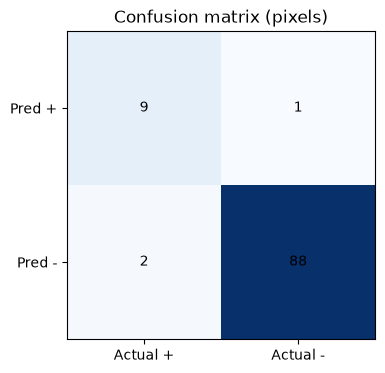

In [36]:
def plot_confusion_matrix(tp, fp, fn, tn, ax=None):
    """Heatmap of the 2x2 pixel confusion matrix from already-summed counts."""
    counts = np.array([[tp, fp], [fn, tn]])
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(counts, cmap="Blues")
    for (i, j), v in np.ndenumerate(counts):
        ax.text(j, i, f"{v:,}", ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Actual +", "Actual -"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Pred +", "Pred -"])
    ax.set_title("Confusion matrix (pixels)")
    return ax.figure


_cm_fig = plot_confusion_matrix(9, 1, 2, 88)
assert _cm_fig.axes[0].images[0].get_array().tolist() == [[9, 1], [2, 88]]
print("plot_confusion_matrix self-check: 2x2 heatmap data matches input counts.")


### 5.2 — Error map

Here we build a 4-category map (TP/FP/FN/TN) for visualizing *where* a model fails, not just how often.

In [37]:
def error_map(pred_mask, true_mask):
    """Categorical array (0=TN, 1=TP, 2=FP, 3=FN) for visualizing where a model fails."""
    pred, true = pred_mask.astype(bool), true_mask.astype(bool)
    out = np.zeros(pred.shape, dtype=np.uint8)
    out[pred & true] = 1
    out[pred & ~true] = 2
    out[~pred & true] = 3
    return out


_pred = np.array([[1, 1, 0], [0, 0, 1]], dtype=bool)
_true = np.array([[1, 0, 0], [0, 1, 1]], dtype=bool)
_em = error_map(_pred, _true)
assert _em.tolist() == [[1, 2, 0], [0, 3, 1]]

### 5.3 — Per-cluster aggregation

Here we summarize per-cluster metrics (mean/std/min/max across held-out folds) into one table, so a model that does well on most clusters but badly on one doesn't hide behind a single pooled number.

In [38]:
def aggregate_fold_metrics(per_cluster_metrics):
    """Mean/std/min/max across held-out clusters -- a pooled number alone can hide one bad cluster."""
    df = pd.DataFrame(per_cluster_metrics)
    summary = df.drop(columns=["cluster"]).agg(["mean", "std", "min", "max"])
    return df, summary


# Synthetic per-cluster results, deliberately uneven so the summary's spread is checked.
_fold_metrics = [
    {"cluster": 0, "precision": 0.80, "recall": 0.70, "f1": 0.75, "iou": 0.60},
    {"cluster": 1, "precision": 0.40, "recall": 0.35, "f1": 0.37, "iou": 0.23},
    {"cluster": 2, "precision": 0.75, "recall": 0.68, "f1": 0.71, "iou": 0.55},
]
_per_fold_df, _fold_summary = aggregate_fold_metrics(_fold_metrics)
assert _fold_summary.loc["min", "f1"] < _fold_summary.loc["mean", "f1"] < _fold_summary.loc["max", "f1"]
print(_per_fold_df)
print(_fold_summary)

   cluster  precision  recall    f1   iou
0        0       0.80    0.70  0.75  0.60
1        1       0.40    0.35  0.37  0.23
2        2       0.75    0.68  0.71  0.55
      precision    recall        f1       iou
mean   0.650000  0.576667  0.610000  0.460000
std    0.217945  0.196554  0.208806  0.200749
min    0.400000  0.350000  0.370000  0.230000
max    0.800000  0.700000  0.750000  0.600000


### 5.4 -- Classical baseline & elevation-confound check


In [39]:
def patch_scalar_features(dataset):
    """Per-patch mean elevation + mean slope (recomputed from the dataset's
    own DEM window, not the CNN's channel stack) plus a patch-level
    positive/negative label -- tabular features for the classical-baseline
    and elevation-confound checks below.
    """
    slope, _ = slope_aspect(dataset.dem, dataset.resolution_m)
    rows = []
    for centroid_xy in dataset.centroids_xy:
        win = positive_patch_window(centroid_xy, dataset.transform, size=dataset.size)
        r0, c0, h, w = win.row_off, win.col_off, win.height, win.width
        rows.append({
            "mean_elevation": float(np.mean(dataset.dem[r0:r0 + h, c0:c0 + w])),
            "mean_slope": float(np.mean(slope[r0:r0 + h, c0:c0 + w])),
            "is_positive": bool(np.any(dataset.mask_full[r0:r0 + h, c0:c0 + w])),
        })
    return pd.DataFrame(rows)


def classical_baseline_auc(dataset, test_size=1 / 3, random_state=0):
    """Sklearn logistic-regression baseline on mean elevation + slope only
    (no CNN, no GPU) -- a documented sanity-check floor. If this alone gets
    non-trivial AUC, the CNN comparison should be judged against it.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score
    feats = patch_scalar_features(dataset)
    if feats["is_positive"].nunique() < 2:
        return float("nan")
    X, y = feats[["mean_elevation", "mean_slope"]].to_numpy(), feats["is_positive"].to_numpy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)
    if len(set(y_test)) < 2:
        return float("nan")
    clf = LogisticRegression().fit(X_train, y_train)
    return roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])


def elevation_confound_check(dataset, n_bins=5, rng=None):
    """Elevation-matched control: bins patches by mean_elevation, balances
    positive/negative counts within each bin, then reports slope-only AUC
    on that matched subset -- if slope still separates classes once
    elevation is controlled for, slope isn't just an elevation proxy.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score
    rng = rng or np.random.default_rng(RANDOM_SEED)
    feats = patch_scalar_features(dataset)
    n_bins = min(n_bins, feats["mean_elevation"].nunique())
    feats["elev_bin"] = pd.qcut(feats["mean_elevation"], q=n_bins, duplicates="drop")
    matched_idx = []
    for _, group in feats.groupby("elev_bin", observed=True):
        pos, neg = group[group["is_positive"]], group[~group["is_positive"]]
        k = min(len(pos), len(neg))
        if k == 0:
            continue
        matched_idx.extend(rng.choice(pos.index, size=k, replace=False))
        matched_idx.extend(rng.choice(neg.index, size=k, replace=False))
    matched = feats.loc[matched_idx]
    if matched.empty or matched["is_positive"].nunique() < 2:
        return float("nan"), matched
    X, y = matched[["mean_slope"]].to_numpy(), matched["is_positive"].to_numpy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
    if len(set(y_test)) < 2:
        return float("nan"), matched
    clf = LogisticRegression().fit(X_train, y_train)
    return roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]), matched


_cb_scene = 1000
_cb_dem = np.fromfunction(lambda r, c: c * 1.0, (_cb_scene, _cb_scene))
_cb_mask_full = np.zeros((_cb_scene, _cb_scene), dtype=np.uint8)
_cb_mask_full[:, 600:1000] = 1
_cb_transform = from_origin(0, _cb_scene * 10, 10, 10)
_cb_centroids = [(1000, 5000), (1500, 5000), (2000, 5000), (2500, 5000), (3000, 5000), (3500, 5000),
                 (7000, 5000), (7500, 5000), (8000, 5000), (8500, 5000), (9000, 5000), (9500, 5000)]
_cb_dataset = LandslideDataset(_cb_centroids, None, _cb_dem, _cb_mask_full, _cb_transform,
                                resolution_m=10, size=64)

_psf_feats = patch_scalar_features(_cb_dataset)
assert set(_psf_feats.columns) == {"mean_elevation", "mean_slope", "is_positive"}
assert len(_psf_feats) == 12 and _psf_feats["is_positive"].sum() == 6
print("patch_scalar_features self-check: 12 patches, labels match construction.")

_cb_auc = classical_baseline_auc(_cb_dataset, test_size=1 / 3, random_state=0)
assert 0.0 <= _cb_auc <= 1.0
print(f"classical_baseline_auc self-check: AUC={_cb_auc:.3f} on 12 synthetic patches.")

# elevation/label are perfectly correlated here, n_bins=2 matches the
# low/high split exactly -> both bins single-class -> empty match/nan.
_ec_auc, _ec_matched = elevation_confound_check(_cb_dataset, n_bins=2, rng=np.random.default_rng(0))
assert len(_ec_matched) == 0 and _ec_auc != _ec_auc
print("elevation_confound_check self-check: perfectly-confounded synthetic case -> empty match, AUC=nan.")


patch_scalar_features self-check: 12 patches, labels match construction.

classical_baseline_auc self-check: AUC=1.000 on 12 synthetic patches.
elevation_confound_check self-check: perfectly-confounded synthetic case -> empty match, AUC=nan.


### 5.5 — Real prediction check

Here we run the just-trained real model on its own real training patches and compute real segmentation metrics — proof the whole chain (real imagery -> real patches -> real training -> real prediction -> real metrics) works end to end. This is **not** a held-out evaluation (predicting on training data trivially overfits) — a genuine evaluation needs the full-scale download so `buffered_cluster_folds` has enough real polygons per cluster to hold out meaningfully.

In [40]:
def predict_and_score(model, dataset, batch_size=32, max_samples=None):
    """Scores samples in a dataset -- a mechanism check, not held-out
    evaluation. Batched (not one sample at a time) for GPU throughput.
    max_samples bounds it to a random subsample: the per-sample metrics are
    unchanged, there are simply fewer rows, which is enough for a check that
    only has to show the prediction path works.
    """
    model.eval()
    rows = []
    scored = dataset
    if max_samples is not None and len(dataset) > max_samples:
        _rng = np.random.default_rng(RANDOM_SEED)
        _pick = _rng.choice(len(dataset), size=max_samples, replace=False).tolist()
        scored = torch.utils.data.Subset(dataset, _pick)
    loader = torch.utils.data.DataLoader(
        scored, batch_size=min(batch_size, len(scored)), shuffle=False,
        num_workers=4 if IN_COLAB else 0, pin_memory=(DEVICE.type == "cuda"))
    use_amp = DEVICE.type == "cuda"
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                logits = model(x)
            preds = (torch.sigmoid(logits)[:, 0] > 0.5).cpu().numpy()
            trues = y.numpy() > 0.5
            for pred, true in zip(preds, trues):
                rows.append(segmentation_metrics(pred, true))
    return pd.DataFrame(rows)


_pc_scene = 600
_pc_dem = np.fromfunction(lambda r, c: c * 1.5, (_pc_scene, _pc_scene))
_pc_mask_full = np.zeros((_pc_scene, _pc_scene), dtype=np.uint8)
_pc_transform = from_origin(0, _pc_scene * 10, 10, 10)
_pc_centroids = [(2500, 2500), (3000, 3000)]

# builds its own scene rather than reusing an earlier one whose temp dir is already gone
with tempfile.TemporaryDirectory() as _pc_tmp:
    _pc_tif_path = Path(_pc_tmp) / "synthetic_scene.tif"
    _pc_arr = (np.random.rand(len(BAND_ORDER) + 1, _pc_scene, _pc_scene) * 3000).astype(np.int16)
    _pc_arr[-1] = 4
    with rasterio.open(_pc_tif_path, "w", driver="GTiff", height=_pc_scene, width=_pc_scene,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_pc_transform) as _dst:
        _dst.write(_pc_arr)

    _pc_dataset = LandslideDataset(_pc_centroids, _pc_tif_path, _pc_dem, _pc_mask_full,
                                    _pc_transform, resolution_m=10, size=64)
    _predict_check_scores = predict_and_score(_synthetic_model, _pc_dataset)
    assert len(_predict_check_scores) == len(_pc_dataset)
    del _pc_dataset  # closes the open handle before the temp dir cleans up

assert set(_predict_check_scores.columns) == {"precision", "recall", "f1", "iou", "accuracy",
                                              "balanced_accuracy", "specificity", "tp", "fp", "fn", "tn"}

### 5.6 -- Geographic error map & qualitative sample grid


export_error_map_rows / plot_geographic_error_map / plot_sample_grid / grad_cam self-checks passed.


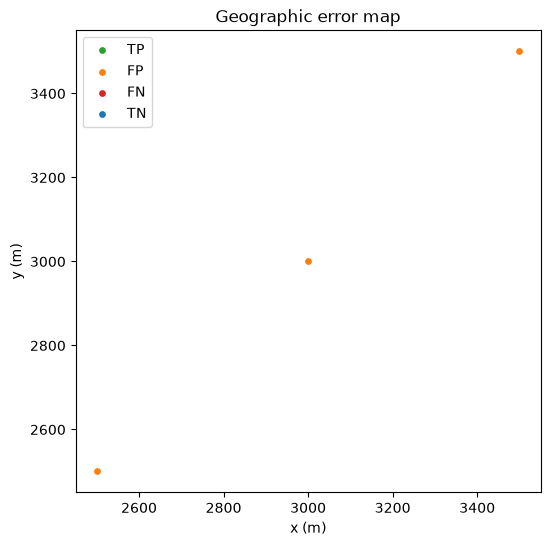

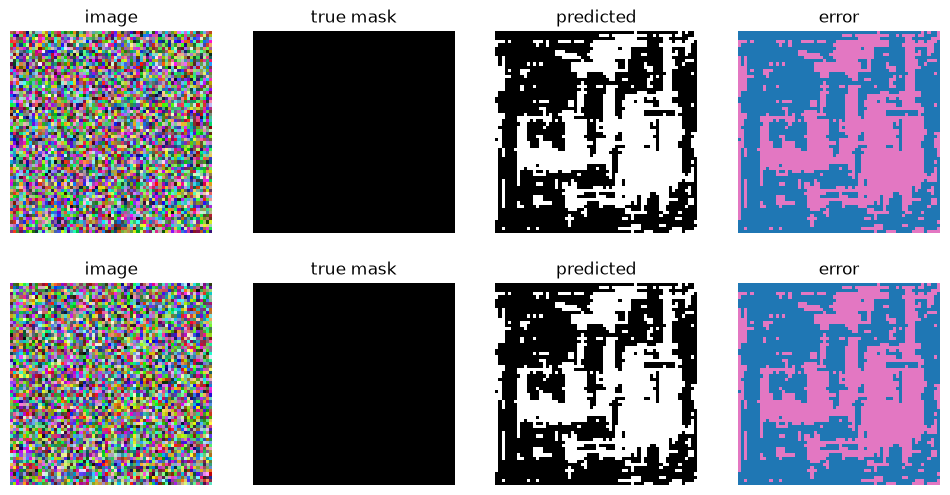

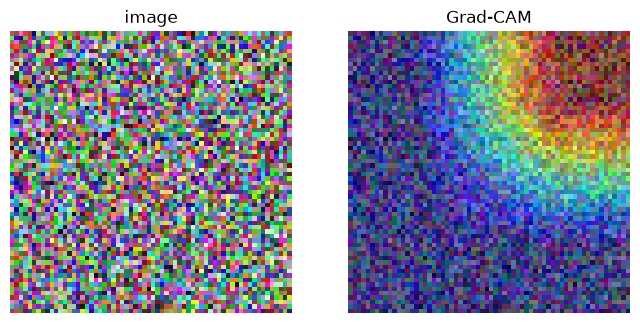

In [41]:
def export_error_map_rows(model, dataset, batch_size=16):
    """Per-patch prediction rows for geographic error-map plotting -- reuses
    predict_and_score's counts, adds each patch's centroid + a 4-way
    TP/FP/FN/TN category (does the patch contain a real positive vs. did
    the model predict one).
    """
    scores = predict_and_score(model, dataset, batch_size=batch_size).copy()
    scores["centroid_x"] = [c[0] for c in dataset.centroids_xy]
    scores["centroid_y"] = [c[1] for c in dataset.centroids_xy]
    has_positive = (scores["tp"] + scores["fn"]) > 0
    predicted_positive = (scores["tp"] + scores["fp"]) > 0
    scores["category"] = np.select(
        [has_positive & (scores["tp"] > 0), has_positive & (scores["tp"] == 0),
         ~has_positive & predicted_positive],
        ["TP", "FN", "FP"], default="TN")
    return scores


def plot_geographic_error_map(rows, ax=None):
    """Scatter of patch centroids colored by TP/FP/FN/TN category."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    colors = {"TP": "tab:green", "FP": "tab:orange", "FN": "tab:red", "TN": "tab:blue"}
    for cat, color in colors.items():
        sub = rows[rows["category"] == cat]
        ax.scatter(sub["centroid_x"], sub["centroid_y"], c=color, label=cat, s=15)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.set_title("Geographic error map")
    ax.legend()
    return ax.figure


def plot_sample_grid(model, dataset, n=4, rng=None):
    """Grid of (image RGB, true mask, predicted mask, error map) for n
    randomly chosen samples -- a qualitative check alongside aggregate metrics.
    """
    rng = rng or np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    model.eval()
    fig, axes = plt.subplots(len(idx), 4, figsize=(12, 3 * len(idx)))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for row, i in enumerate(idx):
            x, y = dataset[i]
            logits = model(x.unsqueeze(0).to(DEVICE))
            pred = (torch.sigmoid(logits)[0, 0] > 0.5).cpu().numpy()
            true = y.numpy() > 0.5
            rgb = x[[2, 1, 0]].permute(1, 2, 0).numpy()  # B04/B03/B02 -> RGB
            rgb = np.clip(rgb / max(rgb.max(), 1e-6), 0, 1)
            axes[row, 0].imshow(rgb); axes[row, 0].set_title("image")
            axes[row, 1].imshow(true, cmap="gray"); axes[row, 1].set_title("true mask")
            axes[row, 2].imshow(pred, cmap="gray"); axes[row, 2].set_title("predicted")
            axes[row, 3].imshow(error_map(pred, true), cmap="tab10", vmin=0, vmax=3)
            axes[row, 3].set_title("error")
    for ax in axes.ravel():
        ax.axis("off")
    return fig


def grad_cam(model, x, target_layer=None):
    """Grad-CAM heatmap for a single input patch -- gradient-weighted
    activation map of the encoder's last Conv2d layer, upsampled to input
    resolution.
    """
    def _last_conv(module):
        convs = [m for m in module.modules() if isinstance(m, torch.nn.Conv2d)]
        if not convs:
            raise ValueError("no Conv2d layer found in module")
        return convs[-1]

    model.eval()
    activations, gradients = {}, {}
    layer = target_layer or _last_conv(model.encoder)

    def fwd_hook(_, __, out):
        activations["value"] = out

    def bwd_hook(_, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    h1 = layer.register_forward_hook(fwd_hook)
    h2 = layer.register_full_backward_hook(bwd_hook)
    try:
        xb = x.unsqueeze(0).to(DEVICE).requires_grad_(True)
        logits = model(xb)
        score = logits.mean()
        model.zero_grad()
        score.backward()
        acts, grads = activations["value"][0], gradients["value"][0]
        weights = grads.mean(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * acts).sum(dim=0))
        cam = cam / (cam.max() + 1e-8)
        cam = torch.nn.functional.interpolate(
            cam[None, None], size=xb.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
        return cam.detach().cpu().numpy()
    finally:
        h1.remove(); h2.remove()


def plot_grad_cam(model, dataset, idx=0, target_layer=None):
    """Grad-CAM overlay (image + heatmap) for one dataset sample --
    interpretability check: does the model's attention concentrate where
    the landslide actually is?
    """
    x, _ = dataset[idx]
    cam = grad_cam(model, x, target_layer)
    rgb = x[[2, 1, 0]].permute(1, 2, 0).numpy()
    rgb = np.clip(rgb / max(rgb.max(), 1e-6), 0, 1)
    fig, (ax_img, ax_cam) = plt.subplots(1, 2, figsize=(8, 4))
    ax_img.imshow(rgb); ax_img.set_title("image"); ax_img.axis("off")
    ax_cam.imshow(rgb); ax_cam.imshow(cam, cmap="jet", alpha=0.5)
    ax_cam.set_title("Grad-CAM"); ax_cam.axis("off")
    return fig


_gm_scene = 600
_gm_dem = np.fromfunction(lambda r, c: c * 1.5, (_gm_scene, _gm_scene))
_gm_mask_full = np.zeros((_gm_scene, _gm_scene), dtype=np.uint8)
_gm_transform = from_origin(0, _gm_scene * 10, 10, 10)
_gm_centroids = [(2500, 2500), (3000, 3000), (3500, 3500)]

with tempfile.TemporaryDirectory() as _gm_tmp:
    _gm_tif_path = Path(_gm_tmp) / "synthetic_scene.tif"
    _gm_arr = (np.random.rand(len(BAND_ORDER) + 1, _gm_scene, _gm_scene) * 3000).astype(np.int16)
    _gm_arr[-1] = 4
    with rasterio.open(_gm_tif_path, "w", driver="GTiff", height=_gm_scene, width=_gm_scene,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_gm_transform) as _dst:
        _dst.write(_gm_arr)

    _gm_dataset = LandslideDataset(_gm_centroids, _gm_tif_path, _gm_dem, _gm_mask_full,
                                    _gm_transform, resolution_m=10, size=64)
    _gm_model = build_model("baseline", in_channels=_in_channels, encoder_weights=None)

    _err_rows = export_error_map_rows(_gm_model, _gm_dataset)
    assert {"centroid_x", "centroid_y", "category"} <= set(_err_rows.columns)
    assert set(_err_rows["category"]) <= {"TP", "FP", "FN", "TN"}
    _err_fig = plot_geographic_error_map(_err_rows)
    assert len(_err_fig.axes) == 1

    _grid_fig = plot_sample_grid(_gm_model, _gm_dataset, n=2)
    assert len(_grid_fig.axes) == 2 * 4

    _gm_x0, _ = _gm_dataset[0]
    _cam = grad_cam(_gm_model, _gm_x0)
    assert _cam.shape == (64, 64)
    assert _cam.min() >= 0.0 and _cam.max() <= 1.0 + 1e-6
    _cam_fig = plot_grad_cam(_gm_model, _gm_dataset, idx=0)
    assert len(_cam_fig.axes) == 2
    del _gm_dataset  # closes the open handle before the temp dir cleans up

print("export_error_map_rows / plot_geographic_error_map / plot_sample_grid / grad_cam self-checks passed.")


Run once 4.6 has produced `real_model` — needs a real trained model, not executed automatically.

In [ ]:
# Bounded to a random 1,500 patches. This cell is a mechanism check on data the
# model was trained on, not an evaluation, so a subsample demonstrates exactly
# the same thing. The real evaluation is the held-out spatial CV in 5.8.
real_scores = predict_and_score(real_model, real_dataset, max_samples=1500)
real_scores

### 5.8 — Real held-out spatial cross-validation

5.4 above trains once and predicts on its own training data — a mechanism
check, explicitly not an evaluation. Here we run the real thing: one fold
per cluster (`buffered_cluster_folds`, Step 3), each fold training its own
model on every other cluster (buffer-excluded) and evaluating only on the
held-out cluster — genuine held-out evaluation, not train-and-predict-on-
itself. Reports the pooled confusion matrix, precision/recall/f1/iou, and
ROC-AUC per fold, and saves each fold's model to `models/cv_folds/`.

plot_roc_pr_curves self-check: ROC + PR figure built end to end.


plot_threshold_sweep self-check: 19-point sweep, figure built end to end.


Epoch - 1/1 running, 0/1 remain - 0/1 completed | time remaining approx. estimating...


  epoch 1 breakdown: data-loading 0.0min (5%), GPU compute 0.0min (95%)


Epoch - 1/1 completed: train_loss=0.5833, val_loss=1.9302 (0.1min elapsed, ~0min 0sec left)


Fold cluster=0: train=2 test=1 -> f1=0.000 iou=0.000 roc_auc=0.390 (saved C:\Users\hasha\AppData\Local\Temp\tmp_k2rh7gr\cv_folds\fold_cluster0_baseline.pt)


Epoch - 1/1 running, 0/1 remain - 0/1 completed | time remaining approx. estimating...


  epoch 1 breakdown: data-loading 0.0min (4%), GPU compute 0.0min (96%)
Epoch - 1/1 completed: train_loss=0.5571 (0.0min elapsed, ~0min 0sec left)


Fold cluster=1: train=1 test=2 -> f1=0.000 iou=0.000 roc_auc=0.486 (saved C:\Users\hasha\AppData\Local\Temp\tmp_k2rh7gr\cv_folds\fold_cluster1_baseline.pt)
run_spatial_cv self-check: 2-fold held-out CV loop verified end to end.
   cluster  n_train  n_test  precision  recall   f1  iou   roc_auc
0        0        2       1        0.0     0.0  0.0  0.0  0.389847
1        1        1       2        0.0     0.0  0.0  0.0  0.485990


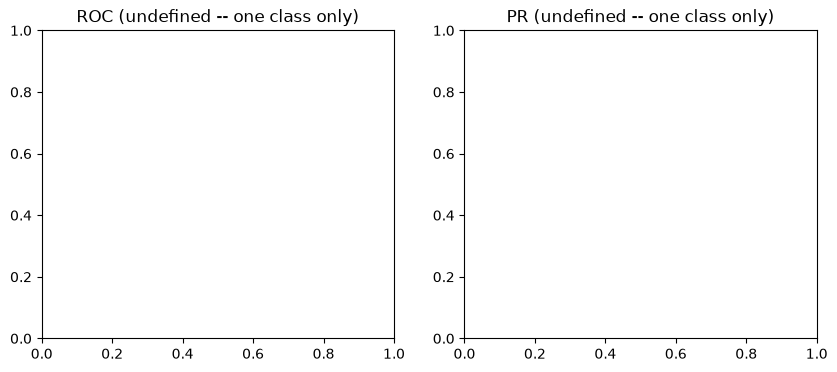

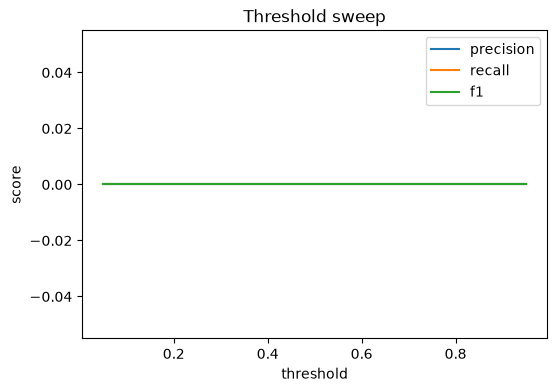

In [43]:
def _collect_probs_and_labels(model, dataset, max_pixels=2_000_000, rng=None, batch_size=16):
    """Batched inference collecting per-pixel probabilities + labels, bounded
    to max_pixels -- shared by roc_auc_for_dataset and plot_roc_pr_curves.
    """
    rng = rng or np.random.default_rng(RANDOM_SEED)
    model.eval()
    order = rng.permutation(len(dataset)).tolist()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(dataset, order), batch_size=min(batch_size, len(dataset)), shuffle=False,
        num_workers=2 if IN_COLAB else 0, pin_memory=(DEVICE.type == "cuda"))
    use_amp = DEVICE.type == "cuda"
    probs_chunks, true_chunks, n_collected = [], [], 0
    with torch.no_grad():
        for x, y in loader:
            if n_collected >= max_pixels:
                break
            x = x.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                logits = model(x)
            probs_chunks.append(torch.sigmoid(logits)[:, 0].cpu().numpy().ravel())
            true_chunks.append((y.numpy() > 0.5).ravel())
            n_collected += probs_chunks[-1].size
    all_probs = np.concatenate(probs_chunks)
    all_true = np.concatenate(true_chunks)
    if len(all_probs) > max_pixels:
        pick = rng.choice(len(all_probs), size=max_pixels, replace=False)
        all_probs, all_true = all_probs[pick], all_true[pick]
    return all_probs, all_true


def roc_auc_for_dataset(model, dataset, max_pixels=2_000_000, rng=None, batch_size=16):
    """ROC-AUC from a bounded random pixel subsample -- concatenating every
    pixel of a real dataset would risk the OOM class fixed elsewhere this
    session. Batched (not one sample at a time) for GPU throughput.
    """
    from sklearn.metrics import roc_auc_score
    all_probs, all_true = _collect_probs_and_labels(model, dataset, max_pixels, rng, batch_size)
    if all_true.min() == all_true.max():
        return float("nan")  # AUC undefined with only one class present
    return roc_auc_score(all_true, all_probs)


def plot_roc_pr_curves(model, dataset, max_pixels=2_000_000, rng=None, batch_size=16):
    """ROC + precision-recall curves side by side, from the same bounded
    pixel subsample roc_auc_for_dataset uses. PR is the more informative
    curve under heavy class imbalance; ROC is included as the familiar one.
    """
    from sklearn.metrics import roc_curve, precision_recall_curve
    all_probs, all_true = _collect_probs_and_labels(model, dataset, max_pixels, rng, batch_size)
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(10, 4))
    if all_true.min() == all_true.max():
        ax_roc.set_title("ROC (undefined -- one class only)")
        ax_pr.set_title("PR (undefined -- one class only)")
        return fig
    fpr, tpr, _ = roc_curve(all_true, all_probs)
    precision, recall, _ = precision_recall_curve(all_true, all_probs)
    ax_roc.plot(fpr, tpr); ax_roc.plot([0, 1], [0, 1], "--", color="gray")
    ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR"); ax_roc.set_title("ROC curve")
    ax_pr.plot(recall, precision)
    ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision"); ax_pr.set_title("PR curve")
    return fig


_prc_scene = 600
_prc_dem = np.fromfunction(lambda r, c: c * 1.5, (_prc_scene, _prc_scene))
_prc_mask_full = np.zeros((_prc_scene, _prc_scene), dtype=np.uint8)
_prc_transform = from_origin(0, _prc_scene * 10, 10, 10)
_prc_centroids = [(2500, 2500), (3000, 3000)]

with tempfile.TemporaryDirectory() as _prc_tmp:
    _prc_tif_path = Path(_prc_tmp) / "synthetic_scene.tif"
    _prc_arr = (np.random.rand(len(BAND_ORDER) + 1, _prc_scene, _prc_scene) * 3000).astype(np.int16)
    _prc_arr[-1] = 4
    with rasterio.open(_prc_tif_path, "w", driver="GTiff", height=_prc_scene, width=_prc_scene,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_prc_transform) as _dst:
        _dst.write(_prc_arr)
    _prc_dataset = LandslideDataset(_prc_centroids, _prc_tif_path, _prc_dem, _prc_mask_full,
                                     _prc_transform, resolution_m=10, size=64)
    _prc_model = build_model("baseline", in_channels=_in_channels, encoder_weights=None)
    _prc_fig = plot_roc_pr_curves(_prc_model, _prc_dataset, batch_size=2)
    del _prc_dataset  # closes the open handle before the temp dir cleans up

assert len(_prc_fig.axes) == 2
print("plot_roc_pr_curves self-check: ROC + PR figure built end to end.")


def plot_threshold_sweep(model, dataset, thresholds=None, max_pixels=2_000_000, rng=None, batch_size=16):
    """Precision/recall/F1 vs. decision threshold, from the same bounded
    pixel sample roc_auc_for_dataset uses -- shows whether the default 0.5
    threshold is actually a good operating point.
    """
    thresholds = np.linspace(0.05, 0.95, 19) if thresholds is None else thresholds
    all_probs, all_true = _collect_probs_and_labels(model, dataset, max_pixels, rng, batch_size)
    rows = []
    for t in thresholds:
        pred = all_probs > t
        tp = int(np.logical_and(pred, all_true).sum())
        fp = int(np.logical_and(pred, ~all_true).sum())
        fn = int(np.logical_and(~pred, all_true).sum())
        tn = int(np.logical_and(~pred, ~all_true).sum())
        rows.append({"threshold": t, **metrics_from_counts(tp, fp, fn, tn)})
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df["threshold"], df["precision"], label="precision")
    ax.plot(df["threshold"], df["recall"], label="recall")
    ax.plot(df["threshold"], df["f1"], label="f1")
    ax.set_xlabel("threshold"); ax.set_ylabel("score"); ax.set_title("Threshold sweep")
    ax.legend()
    return fig, df


_ts_scene = 600
_ts_dem = np.fromfunction(lambda r, c: c * 1.5, (_ts_scene, _ts_scene))
_ts_mask_full = np.zeros((_ts_scene, _ts_scene), dtype=np.uint8)
_ts_transform = from_origin(0, _ts_scene * 10, 10, 10)
_ts_centroids = [(2500, 2500), (3000, 3000)]

with tempfile.TemporaryDirectory() as _ts_tmp:
    _ts_tif_path = Path(_ts_tmp) / "synthetic_scene.tif"
    _ts_arr = (np.random.rand(len(BAND_ORDER) + 1, _ts_scene, _ts_scene) * 3000).astype(np.int16)
    _ts_arr[-1] = 4
    with rasterio.open(_ts_tif_path, "w", driver="GTiff", height=_ts_scene, width=_ts_scene,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_ts_transform) as _dst:
        _dst.write(_ts_arr)
    _ts_dataset = LandslideDataset(_ts_centroids, _ts_tif_path, _ts_dem, _ts_mask_full,
                                    _ts_transform, resolution_m=10, size=64)
    _ts_model = build_model("baseline", in_channels=_in_channels, encoder_weights=None)
    _ts_fig, _ts_df = plot_threshold_sweep(_ts_model, _ts_dataset, batch_size=2)
    del _ts_dataset  # closes the open handle before the temp dir cleans up

assert len(_ts_df) == 19 and len(_ts_fig.axes) == 1
print("plot_threshold_sweep self-check: 19-point sweep, figure built end to end.")


def run_spatial_cv(labels_gdf, tile_dirs, dem_path, patch_size=None, epochs=None,
                    batch_size=None, buffer_m=None, save_dir=None, encoder_weights="__from_config__",
                    model_key="baseline", max_folds=None):
    """Real held-out spatial CV: trains one model per cluster, evaluated
    only on its own held-out cluster -- unlike predict_and_score's
    train-on-itself check. Trains K models (K=clusters) by default; pass
    max_folds to cap it (still genuine spatial holdout, just fewer of them).
    """
    buffer_m = spatial_cv_cfg["buffer_m"] if buffer_m is None else buffer_m
    ring_m = spatial_cv_cfg["negative_sampling"]["hard_negative_ring_m"]
    full_box = labels_gdf.geometry.union_all().convex_hull.buffer(10_000)
    save_dir = Path(save_dir) if save_dir is not None else (REPO_ROOT / "models" / "cv_folds")

    fold_rows, fold_models = [], {}
    for fold_i, (test_cluster, train_idx, test_idx) in enumerate(buffered_cluster_folds(labels_gdf, buffer_m=buffer_m)):
        if max_folds is not None and fold_i >= max_folds:
            break
        test_geom = labels_gdf.loc[test_idx, "geometry"].union_all().buffer(buffer_m)
        train_allowed = full_box.difference(test_geom)
        test_allowed = labels_gdf.loc[test_idx, "geometry"].union_all().buffer(ring_m)
        train_ids = set(labels_gdf.loc[train_idx, "polygon_id"])
        test_ids = set(labels_gdf.loc[test_idx, "polygon_id"])

        train_dataset, _ = build_real_dataset_all_tiles(
            labels_gdf, tile_dirs, dem_path, patch_size=patch_size,
            allowed_geom=train_allowed, positive_candidate_ids=train_ids)
        test_dataset, _ = build_real_dataset_all_tiles(
            labels_gdf, tile_dirs, dem_path, patch_size=patch_size,
            allowed_geom=test_allowed, positive_candidate_ids=test_ids)

        fold_save_path = save_dir / f"fold_cluster{test_cluster}_{model_key}.pt"
        model, _, _ = train_real(train_dataset, epochs=epochs, batch_size=batch_size,
                                  encoder_weights=encoder_weights, save_path=fold_save_path,
                                  model_key=model_key)
        fold_models[test_cluster] = model

        scores = predict_and_score(model, test_dataset)
        pooled = scores[["tp", "fp", "fn", "tn"]].sum()
        row = metrics_from_counts(pooled["tp"], pooled["fp"], pooled["fn"], pooled["tn"])
        row["roc_auc"] = roc_auc_for_dataset(model, test_dataset)
        row["cluster"] = test_cluster
        row["n_train"], row["n_test"] = len(train_dataset), len(test_dataset)
        fold_rows.append(row)
        print(f"Fold cluster={test_cluster}: train={row['n_train']} test={row['n_test']} "
              f"-> f1={row['f1']:.3f} iou={row['iou']:.3f} roc_auc={row['roc_auc']:.3f} "
              f"(saved {fold_save_path})")

    per_fold_df, fold_summary = aggregate_fold_metrics(fold_rows)
    return per_fold_df, fold_summary, fold_models


# Self-check: 2 synthetic clusters far enough apart for buffered_cluster_folds to
# cleanly separate -- proves the whole loop (candidate restriction, allowed_geom,
# per-fold save, pooled confusion matrix, roc_auc) works end to end.
_cv_scene = 400
_cv_dem = np.fromfunction(lambda r, c: c * 1.5, (_cv_scene, _cv_scene)).astype(np.float64)
_cv_transform = from_origin(0, _cv_scene * 10, 10, 10)
_cv_labels = gpd.GeoDataFrame(
    {"polygon_id": [0, 1], "minor_axis_m": [80.0, 80.0], "cluster": [0, 1]},
    geometry=[box(1950, 1950, 2050, 2050), box(7450, 7450, 7550, 7550)],
    crs=METRIC_CRS,
)

with tempfile.TemporaryDirectory() as _cv_tmp:
    _cv_tile_dir = Path(_cv_tmp) / "tile0"
    _cv_tile_dir.mkdir()
    _cv_tif_path = _cv_tile_dir / "openEO_2025-01-01Z.tif"
    _cv_arr = (np.random.rand(len(BAND_ORDER) + 1, _cv_scene, _cv_scene) * 3000).astype(np.int16)
    _cv_arr[-1] = 4
    with rasterio.open(_cv_tif_path, "w", driver="GTiff", height=_cv_scene, width=_cv_scene,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_cv_transform) as _dst:
        _dst.write(_cv_arr)

    _cv_dem_path = Path(_cv_tmp) / "dem.tif"
    with rasterio.open(_cv_dem_path, "w", driver="GTiff", height=_cv_scene, width=_cv_scene, count=1,
                        dtype="float64", crs=METRIC_CRS, transform=_cv_transform) as _dst:
        _dst.write(_cv_dem, 1)

    _cv_per_fold_df, _cv_summary, _cv_models = run_spatial_cv(
        _cv_labels, [_cv_tile_dir], _cv_dem_path, epochs=1, batch_size=1,
        save_dir=Path(_cv_tmp) / "cv_folds", encoder_weights=None)

assert len(_cv_per_fold_df) == 2
assert set(_cv_per_fold_df["cluster"]) == {0, 1}
assert set(_cv_models.keys()) == {0, 1}

# max_folds=1 must train/evaluate exactly one cluster, not both -- rebuild
# fresh tile/dem files since the earlier temp dir is already cleaned up.
with tempfile.TemporaryDirectory() as _cv_tmp1:
    _cv_tile_dir1 = Path(_cv_tmp1) / "tile0"
    _cv_tile_dir1.mkdir()
    _cv_tif_path1 = _cv_tile_dir1 / "openEO_2025-01-01Z.tif"
    with rasterio.open(_cv_tif_path1, "w", driver="GTiff", height=_cv_scene, width=_cv_scene,
                        count=len(BAND_ORDER) + 1, dtype="int16", crs=METRIC_CRS,
                        transform=_cv_transform) as _dst:
        _dst.write(_cv_arr)
    _cv_dem_path1 = Path(_cv_tmp1) / "dem.tif"
    with rasterio.open(_cv_dem_path1, "w", driver="GTiff", height=_cv_scene, width=_cv_scene, count=1,
                        dtype="float64", crs=METRIC_CRS, transform=_cv_transform) as _dst:
        _dst.write(_cv_dem, 1)
    _cv_df1, _, _cv_models1 = run_spatial_cv(
        _cv_labels, [_cv_tile_dir1], _cv_dem_path1, epochs=1, batch_size=1,
        save_dir=Path(_cv_tmp1) / "cv_folds", encoder_weights=None, max_folds=1)
assert len(_cv_df1) == 1 and len(_cv_models1) == 1
print("run_spatial_cv max_folds self-check: capped to 1 fold as requested.")
assert {"precision", "recall", "f1", "iou", "tp", "fp", "fn", "tn", "roc_auc"} <= set(_cv_per_fold_df.columns)
print("run_spatial_cv self-check: 2-fold held-out CV loop verified end to end.")
print(_cv_per_fold_df[["cluster", "n_train", "n_test", "precision", "recall", "f1", "iou", "roc_auc"]])

plot_model_comparison self-check: grouped bars for 2 models x 3 metrics rendered.


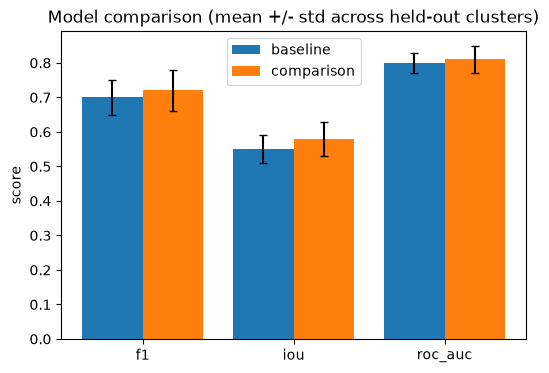

In [44]:
def plot_model_comparison(fold_summaries, metrics=("f1", "iou", "roc_auc"), ax=None):
    """Grouped bar chart (mean +/- std across held-out clusters) comparing
    architectures. fold_summaries maps a model name to the `summary`
    DataFrame aggregate_fold_metrics/run_spatial_cv already returns.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    names = list(fold_summaries.keys())
    width = 0.8 / len(names)
    x = np.arange(len(metrics))
    for i, name in enumerate(names):
        summary = fold_summaries[name]
        means = [summary.loc["mean", m] for m in metrics]
        stds = [summary.loc["std", m] for m in metrics]
        ax.bar(x + i * width, means, width, yerr=stds, capsize=3, label=name)
    ax.set_xticks(x + width * (len(names) - 1) / 2)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("score")
    ax.set_title("Model comparison (mean +/- std across held-out clusters)")
    ax.legend()
    return ax.figure


_mc_baseline = pd.DataFrame({"f1": [0.70, 0.05], "iou": [0.55, 0.04], "roc_auc": [0.80, 0.03]},
                            index=["mean", "std"])
_mc_comparison = pd.DataFrame({"f1": [0.72, 0.06], "iou": [0.58, 0.05], "roc_auc": [0.81, 0.04]},
                              index=["mean", "std"])
_mc_fig = plot_model_comparison({"baseline": _mc_baseline, "comparison": _mc_comparison})
assert len(_mc_fig.axes[0].patches) == 2 * 3
print("plot_model_comparison self-check: grouped bars for 2 models x 3 metrics rendered.")


### 5.9 -- Bootstrap CI & multi-seed reruns


In [45]:
def bootstrap_fold_ci(per_fold_df, metrics=("precision", "recall", "f1", "iou", "roc_auc"),
                       n_boot=1000, ci=0.95, rng=None):
    """Percentile bootstrap CI per metric, resampling FOLDS (not patches) --
    each held-out cluster is one independent observation, which is the
    right resampling unit for cross-cluster generalization variance.
    """
    rng = rng or np.random.default_rng(RANDOM_SEED)
    n = len(per_fold_df)
    lo_q, hi_q = (1 - ci) / 2, 1 - (1 - ci) / 2
    rows = []
    for m in metrics:
        vals = per_fold_df[m].to_numpy()
        boot_means = [vals[rng.integers(0, n, size=n)].mean() for _ in range(n_boot)]
        rows.append({"metric": m, "mean": vals.mean(),
                     "ci_lo": np.quantile(boot_means, lo_q), "ci_hi": np.quantile(boot_means, hi_q)})
    return pd.DataFrame(rows)


def run_multi_seed(train_fn, seeds, *args, **kwargs):
    """Runs train_fn once per seed (torch.manual_seed'd beforehand) -- lets
    the caller report mean/std across initialization seeds instead of a
    single run. Works for train_real or run_spatial_cv equally.
    """
    results = []
    for seed in seeds:
        torch.manual_seed(seed)
        results.append(train_fn(*args, **kwargs))
    return results


def aggregate_multi_seed_folds(list_of_per_fold_dfs, metrics=("precision", "recall", "f1", "iou", "roc_auc")):
    """Mean/std across seeds AND folds combined, given a list of per_fold_df
    (one per seed) from repeated run_spatial_cv calls.
    """
    combined = pd.concat(list_of_per_fold_dfs, ignore_index=True)
    return combined[list(metrics)].agg(["mean", "std"])


_bs_fold_df = pd.DataFrame([
    {"cluster": 0, "precision": 0.80, "recall": 0.70, "f1": 0.75, "iou": 0.60, "roc_auc": 0.85},
    {"cluster": 1, "precision": 0.40, "recall": 0.35, "f1": 0.37, "iou": 0.23, "roc_auc": 0.55},
    {"cluster": 2, "precision": 0.75, "recall": 0.68, "f1": 0.71, "iou": 0.55, "roc_auc": 0.80},
])
_bs_ci = bootstrap_fold_ci(_bs_fold_df, n_boot=200, rng=np.random.default_rng(0))
assert (_bs_ci["ci_lo"] <= _bs_ci["mean"]).all() and (_bs_ci["mean"] <= _bs_ci["ci_hi"]).all()
print("bootstrap_fold_ci self-check: mean falls within its own CI for every metric.")

def _stub_train():
    return torch.rand(1).item()

_ms_results = run_multi_seed(_stub_train, seeds=[1, 2, 1])
assert _ms_results[0] == _ms_results[2], "same seed must reproduce the same result"
assert _ms_results[0] != _ms_results[1], "different seeds should (almost certainly) differ"
print("run_multi_seed self-check: same seed reproducible, different seeds differ.")

_msf_combined = aggregate_multi_seed_folds([_bs_fold_df, _bs_fold_df])
assert _msf_combined.loc["mean", "f1"] == _bs_fold_df["f1"].mean()
print("aggregate_multi_seed_folds self-check: combined mean matches a doubled-up fold set.")


bootstrap_fold_ci self-check: mean falls within its own CI for every metric.
run_multi_seed self-check: same seed reproducible, different seeds differ.
aggregate_multi_seed_folds self-check: combined mean matches a doubled-up fold set.


Run once 2.2/2.3 have produced real `s2_paths`/`dem_path` — needs real data,
not executed automatically. Trains one model per cluster (see docstring
above) — K times the cost of a single 4.6-style run, not a bug.

In [ ]:
# max_folds=1: one real spatial-holdout fold (not all 8 clusters) -- fast,
# still genuine held-out spatial evaluation. Raise/remove max_folds later
# for the full multi-cluster variance estimate.
cv_per_fold_df, cv_summary, cv_fold_models = run_spatial_cv(labels, s2_paths, dem_path, max_folds=1)
print(cv_per_fold_df)
print(cv_summary)

In [ ]:
# Visual outputs for the real spatial-CV results above.
plot_confusion_matrix(*cv_per_fold_df[["tp", "fp", "fn", "tn"]].sum())
plot_model_comparison({"baseline": cv_summary})
plt.show()


### 5.10 -- Real comparison-model spatial CV (DeepLabV3+)

Run once 5.5's baseline CV above has completed -- trains the comparison
architecture through the identical CV loop via `model_key="comparison"`.
Needs real data, not executed automatically; roughly doubles total real-run cost.


In [ ]:
# max_folds=1 to match the baseline in 5.8. Without it this cell trained one
# DeepLabV3+ model per cluster -- eight full trainings for a comparison that
# only needs to run on the same fold the baseline used.
cv_per_fold_df_cmp, cv_summary_cmp, cv_fold_models_cmp = run_spatial_cv(
    labels, s2_paths, dem_path, model_key="comparison", max_folds=1)
print(cv_per_fold_df_cmp)
print(cv_summary_cmp)


In [ ]:
# Baseline vs. comparison architecture, real held-out spatial-CV results.
plot_model_comparison({"baseline": cv_summary, "comparison": cv_summary_cmp})
print("baseline 95% CI:\n", bootstrap_fold_ci(cv_per_fold_df))
print("comparison 95% CI:\n", bootstrap_fold_ci(cv_per_fold_df_cmp))
plt.show()


## Step 6 — Write-up notes

This notebook is code, not the report. See `docs/architecture.md` for design rationale.

What's real vs. synthetic-verified-only, end to end:

| Component | Status |
|---|---|
| Label loading + EDA + cluster-balance check (Step 1/3) | **Real** — run against the actual 4,225-polygon shapefile |
| Spatial clustering + buffered CV (Step 3) | **Real** — run against the actual shapefile |
| Sentinel-2 / DEM acquisition (Step 2) | **Real, full-AOI** — tiled batch download (`aoi_tiles`) against the live CDSE API, not a small pilot AOI |
| Cloud mask, indices, terrain incl. curvature, rasterization, patch extraction (Step 2) | Correct logic, synthetic-verified at the function level; exercised against real imagery via `LandslideDataset`/`extract_patch` in 4.2 |
| Real dataset assembly (4.2, `build_real_dataset_all_tiles`) | Implemented, self-checked, and run against real downloaded Sentinel-2 tiles + DEM (2.2/2.3) — reads pixels lazily per patch, nothing to preload separately (2.11) |
| Positive/negative/hard-negative sampling (Step 3) | Correct logic, **synthetic-verified only** at the function level; exercised for real via 4.2 above |
| Dataset streaming, both models, Focal-Dice loss (Step 4) | Mechanically proven (forward pass, overfit-one-batch) |
| Real training run (4.6) | Implemented and self-checked; real (non-dev) config -- `epochs: 20`, not the old 1-epoch placeholder -- and saves to `models/baseline_unet.pt` (`train_real(save_path=...)`) |
| Precision/Recall/F1/mIoU, error map, per-cluster aggregation (Step 5) | Correct logic, **synthetic-verified only** |
| Real prediction check (5.4) | Implemented and self-checked; mechanism proof only, not a held-out evaluation |
| Real held-out spatial CV + confusion matrix + ROC-AUC (5.5, `run_spatial_cv`) | Implemented and self-checked (2-fold synthetic loop, verified end to end) -- trains one model per cluster, evaluates only on its held-out cluster, saves each fold to `models/cv_folds/` |

**Not implemented, by deliberate scope decision (not oversight):** NDVI-variance/elevation-histogram EDA (needs real imagery), NDWI/NBR (MNDWI was chosen over NDWI for better built-up-vs-water separation and NBR is a burn-severity index with no established landslide-susceptibility role), aspect/elevation/land-cover-matched negative stratification (slope-only, documented scope reduction).

Next real step: run Step 2's two download cells with live credentials, then re-run Steps 3-5 against actual imagery.